In [ ]:

# 1. 데이터 경로 설정
B2_PATH = '/Users/hajiyoon/workspace/data/processed/B2_FOOD_POS_SALE.parquet'
B4_PATH = '/Users/hajiyoon/workspace/data/processed/B4_CLEAN_FOOD_ITEM.parquet'

b2_lazy = pl.scan_parquet(B2_PATH)
b4_lazy = pl.scan_parquet(B4_PATH)

In [41]:
# 마스터 데이터 실제 컬럼명 확인을 위해 스키마 미리 보기
b4_columns = b4_lazy.columns
b2_columns = b2_lazy.columns
print(f"🔍 마스터 데이터(B4) 컬럼 목록: {b4_columns}")
print(f"🔍 판매 데이터(B2) 컬럼 목록: {b2_columns}")

🔍 마스터 데이터(B4) 컬럼 목록: ['상품코드', '상품명', '대분류명', '중분류명', '소분류명']
🔍 판매 데이터(B2) 컬럼 목록: ['판매일자', '판매시간', '점포코드', 'POS번호', '거래번호', '상품코드', '판매수량', '판매금액']


In [39]:
import polars as pl
import os

"""
[데이터 기초 점검: B2_FOOD_POS_SALE.parquet]

1. 분석 목적:
   - POS 판매 데이터의 스키마(컬럼명, 데이터 타입)를 파악함.
   - 실제 데이터 샘플을 확인하여 전처리 상태를 점검함.
   - 데이터 규모(행 수) 및 결측치 여부를 진단함.

2. 통계적 방법론:
   - Polars Lazy API를 사용하여 메모리 전체를 로드하지 않고 메타데이터 추출.
   - 전체 행 수 및 컬럼별 Null 값 집계 수행.
"""

# 1. 데이터 경로 설정 (고정된 경로 사용)
B2_PATH = '/Users/hajiyoon/workspace/data/processed/B2_FOOD_POS_SALE.parquet'
B4_PATH = '/Users/hajiyoon/workspace/data/processed/B4_CLEAN_FOOD_ITEM.parquet'

# 경로 존재 여부 확인
if not os.path.exists(B2_PATH):
    print(f"⚠️ 데이터를 찾을 수 없습니다: {B2_PATH}")
    exit()

print(f"🔍 데이터 점검을 시작합니다: {B2_PATH}\n")

# 2. 데이터 스캔 (고정된 변수명 b2_lazy 사용)
b2_lazy = pl.scan_parquet(B2_PATH)
b4_lazy = pl.scan_parquet(B4_PATH) # 마스터 데이터도 규칙에 따라 미리 정의

# 3. 데이터 구조 및 스키마 확인
print("--- [1] 데이터 스키마 (Schema) ---")
for col, dtype in b2_lazy.schema.items():
    print(f"- {col}: {dtype}")
print("\n")

# 4. 데이터 샘플 확인 (상위 5개 행)
print("--- [2] 데이터 샘플 (Top 5 Rows) ---")
sample_df = b2_lazy.head(5).collect()
print(sample_df)
print("\n")

# 5. 데이터 규모 및 결측치 점검
print("--- [3] 데이터 규모 및 결측치 (Null Count) ---")
total_rows = b2_lazy.select(pl.len()).collect().item()
print(f"전체 행(Row) 수: {total_rows:,} 건")

null_counts = b2_lazy.select(pl.all().null_count()).collect()
print("\n컬럼별 결측치 수:")
print(null_counts)

🔍 데이터 점검을 시작합니다: /Users/hajiyoon/workspace/data/processed/B2_FOOD_POS_SALE.parquet

--- [1] 데이터 스키마 (Schema) ---
- 판매일자: String
- 판매시간: String
- 점포코드: String
- POS번호: String
- 거래번호: String
- 상품코드: String
- 판매수량: Int64
- 판매금액: Int64


--- [2] 데이터 샘플 (Top 5 Rows) ---
shape: (5, 8)
┌──────────┬──────────┬──────────┬─────────┬──────────┬──────────┬──────────┬──────────┐
│ 판매일자 ┆ 판매시간 ┆ 점포코드 ┆ POS번호 ┆ 거래번호 ┆ 상품코드 ┆ 판매수량 ┆ 판매금액 │
│ ---      ┆ ---      ┆ ---      ┆ ---     ┆ ---      ┆ ---      ┆ ---      ┆ ---      │
│ str      ┆ str      ┆ str      ┆ str     ┆ str      ┆ str      ┆ i64      ┆ i64      │
╞══════════╪══════════╪══════════╪═════════╪══════════╪══════════╪══════════╪══════════╡
│ 20250523 ┆ 084822   ┆ 12611    ┆ 01      ┆ 13164    ┆ 202316   ┆ 1        ┆ 1000     │
│ 20250523 ┆ 143425   ┆ 17796    ┆ 01      ┆ 59106    ┆ 117969   ┆ 1        ┆ 1200     │
│ 20250523 ┆ 145747   ┆ 54630    ┆ 02      ┆ 03156    ┆ 124518   ┆ 1        ┆ 1200     │
│ 20250523 ┆ 165556   ┆ 18467    ┆ 01 

In [ ]:
import polars as pl
import os

"""
[핵심 상품군(Top 5%) 카테고리 및 아이템 비중 분석]

1. 분석 목적:
   - 매출액 및 판매수량 기준 상위 5% 상품(95th Quantile)을 식별함.
   - 상위 상품군 내 중분류/소분류 카테고리 구성 비율을 파악함.
   - 각 카테고리 내 개별 아이템의 기여도(Concentration)를 분석함.

2. 통계적 방법론:
   - POS 데이터(B2)와 상품 마스터(B4)를 ITEM_CD 기준으로 Inner Join.
   - 상품별 누적 매출/수량 집계 및 상위 5% 임계값 산출.
   - 카테고리별 비중 산출 및 아이템별 점유율(Share) 계산.
"""

# 1. 데이터 경로 설정
B2_PATH = '/Users/hajiyoon/workspace/data/processed/B2_POS_SALE.parquet'
B4_PATH = '/Users/hajiyoon/workspace/data/processed/B4_CLEAN_FOOD_ITEM.parquet'

if not os.path.exists(B2_PATH) or not os.path.exists(B4_PATH):
    print(f"⚠️ 데이터를 찾을 수 없습니다.\n- B2: {B2_PATH}\n- B4: {B4_PATH}")
    exit()

print(f"📊 분석 시작: B2({B2_PATH}), B4({B4_PATH})\n")

# 2. 데이터 로드 및 결합 (Lazy)
b2_lazy = pl.scan_parquet(B2_PATH)
b4_lazy = pl.scan_parquet(B4_PATH)

# 상품별 집계
prod_agg = (
    b2_lazy
    .group_by("상품코드")
    .agg([
        pl.col("판매금액").sum().alias("총매출액"),
        pl.col("판매수량").sum().alias("총판매량")
    ])
)

# B4와 결합 (카테고리 정보 확보)
df_joined = (
    prod_agg
    .join(b4_lazy, left_on="상품코드", right_on="ITEM_CD", how="inner")
)

def analyze_top_5(df, target_col):
    print(f"--- [{target_col}] 기준 상위 5% 분석 ---")
    
    # 1. 상위 5% 임계값 산출
    threshold = df.select(pl.col(target_col).quantile(0.95)).collect().item()
    top_5_df = df.filter(pl.col(target_col) >= threshold).collect()
    
    total_top_val = top_5_df[target_col].sum()
    print(f"상위 5% 상품 수: {len(top_5_df):,}개")
    print(f"기준 임계값: {threshold:,.0f}")
    
    # 2. 중분류 비율
    mid_ratio = (
        top_5_df.group_by("ITEM_MDDV_NM")
        .agg(pl.col(target_col).sum().alias("cat_total"))
        .with_columns((pl.col("cat_total") / total_top_val * 100).alias("ratio"))
        .sort("ratio", descending=True)
    )
    print("\n[중분류별 비중 Top 5]")
    print(mid_ratio.head(5))
    
    # 3. 소분류 비율
    sub_ratio = (
        top_5_df.group_by("ITEM_SMDV_NM")
        .agg(pl.col(target_col).sum().alias("sub_total"))
        .with_columns((pl.col("sub_total") / total_top_val * 100).alias("ratio"))
        .sort("ratio", descending=True)
    )
    print("\n[소분류별 비중 Top 5]")
    print(sub_ratio.head(5))
    
    # 4. 카테고리 내 아이템 비중 (가장 비중 높은 중분류 대상)
    if len(mid_ratio) > 0:
        top_mid = mid_ratio["ITEM_MDDV_NM"][0]
        item_in_cat = (
            top_5_df.filter(pl.col("ITEM_MDDV_NM") == top_mid)
            .with_columns((pl.col(target_col) / pl.col(target_col).sum().over("ITEM_MDDV_NM") * 100).alias("item_share"))
            .select(["ITEM_NM", target_col, "item_share"])
            .sort("item_share", descending=True)
        )
        print(f"\n[최상위 중분류({top_mid}) 내 아이템별 비중 Top 5]")
        print(item_in_cat.head(5))
    print("\n" + "="*50 + "\n")

# 3. 분석 실행
full_data_collected = df_joined.collect()
analyze_top_5(full_data_collected.lazy(), "총매출액")
analyze_top_5(full_data_collected.lazy(), "총판매량")


📊 분석 시작: B2(/Users/hajiyoon/workspace/data/processed/B2_POS_SALE.parquet), B4(/Users/hajiyoon/workspace/data/processed/B4_food_item_data.parquet)

--- [총매출액] 기준 상위 5% 분석 ---
상위 5% 상품 수: 383개
기준 임계값: 46,896,145

[중분류별 비중 Top 5]
shape: (5, 3)
┌──────────────┬────────────┬──────────┐
│ ITEM_MDDV_NM ┆ cat_total  ┆ ratio    │
│ ---          ┆ ---        ┆ ---      │
│ str          ┆ i64        ┆ f64      │
╞══════════════╪════════════╪══════════╡
│ 기능성드링크 ┆ 3475902769 ┆ 8.754479 │
│ 국산맥주     ┆ 2987763410 ┆ 7.525042 │
│ 수입맥주     ┆ 2679016582 ┆ 6.747426 │
│ 생수         ┆ 2533021068 ┆ 6.379718 │
│ 소주         ┆ 2235563990 ┆ 5.630537 │
└──────────────┴────────────┴──────────┘

[소분류별 비중 Top 5]
shape: (5, 3)
┌────────────────┬────────────┬───────────┐
│ ITEM_SMDV_NM   ┆ sub_total  ┆ ratio     │
│ ---            ┆ ---        ┆ ---       │
│ str            ┆ i64        ┆ f64       │
╞════════════════╪════════════╪═══════════╡
│ 캔맥주(중)     ┆ 4247355090 ┆ 10.697475 │
│ 스포츠음료(중) ┆ 1626256002 ┆ 4.095921 

In [42]:
import polars as pl
import os

"""
[핵심 상품군(Top 5%) 카테고리 및 아이템 비중 분석]

1. 분석 목적:
   - 매출액 및 판매수량 기준 상위 5% 상품(95th Quantile)을 식별함.
   - 상위 상품군 내 중분류/소분류 카테고리 구성 비율을 파악함.
   - 각 카테고리 내 개별 아이템의 기여도(Concentration)를 분석함.

2. 통계적 방법론:
   - POS 데이터(B2)와 상품 마스터(B4)를 상품코드 기준으로 Inner Join.
   - 상품별 누적 매출/수량 집계 및 상위 5% 임계값 산출.
   - 카테고리별 비중 산출 및 아이템별 점유율(Share) 계산.
"""

# 1. 데이터 경로 설정 (고정 경로 적용)
B2_PATH = '/Users/hajiyoon/workspace/data/processed/B2_FOOD_POS_SALE.parquet'
B4_PATH = '/Users/hajiyoon/workspace/data/processed/B4_CLEAN_FOOD_ITEM.parquet'

if not os.path.exists(B2_PATH) or not os.path.exists(B4_PATH):
    print(f"⚠️ 데이터를 찾을 수 없습니다.\n- B2: {B2_PATH}\n- B4: {B4_PATH}")
    exit()

print(f"📊 분석 시작: B2({B2_PATH}), B4({B4_PATH})\n")

# 2. 데이터 로드 및 결합 (Lazy, 고정 변수명 적용)
b2_lazy = pl.scan_parquet(B2_PATH)
b4_lazy = pl.scan_parquet(B4_PATH)

# 상품별 집계
prod_agg = (
    b2_lazy
    .group_by("상품코드")
    .agg([
        pl.col("판매금액").sum().alias("총매출액"),
        pl.col("판매수량").sum().alias("총판매량")
    ])
)

# B4와 결합 (카테고리 정보 확보, 확인된 컬럼명 적용)
df_joined = (
    prod_agg
    .join(b4_lazy, on="상품코드", how="inner")
)

def analyze_top_5(df, target_col):
    print(f"--- [{target_col}] 기준 상위 5% 분석 ---")
    
    # 1. 상위 5% 임계값 산출
    threshold = df.select(pl.col(target_col).quantile(0.95)).collect().item()
    top_5_df = df.filter(pl.col(target_col) >= threshold).collect()
    
    total_top_val = top_5_df[target_col].sum()
    print(f"상위 5% 상품 수: {len(top_5_df):,}개")
    print(f"기준 임계값: {threshold:,.0f}")
    
    # 2. 중분류 비율 (확인된 컬럼명 '중분류명' 적용)
    mid_ratio = (
        top_5_df.group_by("중분류명")
        .agg(pl.col(target_col).sum().alias("cat_total"))
        .with_columns((pl.col("cat_total") / total_top_val * 100).alias("ratio"))
        .sort("ratio", descending=True)
    )
    print("\n[중분류별 비중 Top 5]")
    print(mid_ratio.head(5))
    
    # 3. 소분류 비율 (확인된 컬럼명 '소분류명' 적용)
    sub_ratio = (
        top_5_df.group_by("소분류명")
        .agg(pl.col(target_col).sum().alias("sub_total"))
        .with_columns((pl.col("sub_total") / total_top_val * 100).alias("ratio"))
        .sort("ratio", descending=True)
    )
    print("\n[소분류별 비중 Top 5]")
    print(sub_ratio.head(5))
    
    # 4. 카테고리 내 아이템 비중 (가장 비중 높은 중분류 대상, 확인된 컬럼명 '상품명' 적용)
    if len(mid_ratio) > 0:
        top_mid = mid_ratio["중분류명"][0]
        item_in_cat = (
            top_5_df.filter(pl.col("중분류명") == top_mid)
            .with_columns((pl.col(target_col) / pl.col(target_col).sum().over("중분류명") * 100).alias("item_share"))
            .select(["상품명", target_col, "item_share"])
            .sort("item_share", descending=True)
        )
        print(f"\n[최상위 중분류({top_mid}) 내 아이템별 비중 Top 5]")
        print(item_in_cat.head(5))
    print("\n" + "="*50 + "\n")

# 3. 분석 실행
full_data_collected = df_joined.collect()
analyze_top_5(full_data_collected.lazy(), "총매출액")
analyze_top_5(full_data_collected.lazy(), "총판매량")

📊 분석 시작: B2(/Users/hajiyoon/workspace/data/processed/B2_FOOD_POS_SALE.parquet), B4(/Users/hajiyoon/workspace/data/processed/B4_CLEAN_FOOD_ITEM.parquet)

--- [총매출액] 기준 상위 5% 분석 ---
상위 5% 상품 수: 524개
기준 임계값: 83,452,558

[중분류별 비중 Top 5]
shape: (5, 3)
┌──────────────┬────────────┬──────────┐
│ 중분류명     ┆ cat_total  ┆ ratio    │
│ ---          ┆ ---        ┆ ---      │
│ str          ┆ i64        ┆ f64      │
╞══════════════╪════════════╪══════════╡
│ 기능성드링크 ┆ 7718297455 ┆ 7.553216 │
│ 국산맥주     ┆ 6329894440 ┆ 6.194509 │
│ 수입맥주     ┆ 5659206801 ┆ 5.538166 │
│ 생수         ┆ 5509690825 ┆ 5.391848 │
│ 탄산음료     ┆ 5099408031 ┆ 4.99034  │
└──────────────┴────────────┴──────────┘

[소분류별 비중 Top 5]
shape: (5, 3)
┌────────────────┬────────────┬──────────┐
│ 소분류명       ┆ sub_total  ┆ ratio    │
│ ---            ┆ ---        ┆ ---      │
│ str            ┆ i64        ┆ f64      │
╞════════════════╪════════════╪══════════╡
│ 캔맥주(중)     ┆ 8966382009 ┆ 8.774606 │
│ 스포츠음료(중) ┆ 4018621471 ┆ 3.93267  │
│ 500ml이

In [44]:
import polars as pl
import os

"""
[핵심 상품군(Top 10%) 카테고리 및 아이템 비중 분석]

1. 분석 목적:
   - 매출액 및 판매수량 기준 상위 10% 상품(90th Quantile)을 식별함.
   - 상위 상품군 내 중분류/소분류 카테고리 구성 비율을 파악함.
   - 각 카테고리 내 개별 아이템의 기여도(Concentration)를 분석함.

2. 통계적 방법론:
   - POS 데이터(B2)와 상품 마스터(B4)를 상품코드 기준으로 Inner Join.
   - 상품별 누적 매출/수량 집계 및 상위 10% 임계값 산출.
   - 카테고리별 비중 산출 및 아이템별 점유율(Share) 계산.
"""

# 1. 데이터 경로 설정 (고정 경로)
B2_PATH = '/Users/hajiyoon/workspace/data/processed/B2_FOOD_POS_SALE.parquet'
B4_PATH = '/Users/hajiyoon/workspace/data/processed/B4_CLEAN_FOOD_ITEM.parquet'

if not os.path.exists(B2_PATH) or not os.path.exists(B4_PATH):
    print(f"⚠️ 데이터를 찾을 수 없습니다.\n- B2: {B2_PATH}\n- B4: {B4_PATH}")
    exit()

print(f"📊 분석 시작 (상위 10% 기준): B2({B2_PATH}), B4({B4_PATH})\n")

# 2. 데이터 로드 및 결합 (Lazy, 고정 변수명 적용)
b2_lazy = pl.scan_parquet(B2_PATH)
b4_lazy = pl.scan_parquet(B4_PATH)

# 상품별 집계
prod_agg = (
    b2_lazy
    .group_by("상품코드")
    .agg([
        pl.col("판매금액").sum().alias("총매출액"),
        pl.col("판매수량").sum().alias("총판매량")
    ])
)

# B4와 결합 (확인된 컬럼명 '상품코드' 적용)
df_joined = (
    prod_agg
    .join(b4_lazy, on="상품코드", how="inner")
)

def analyze_top_10(df, target_col):
    print(f"--- [{target_col}] 기준 상위 10% 분석 ---")
    
    # 1. 상위 10% 임계값 산출 (0.95 -> 0.90으로 수정)
    threshold = df.select(pl.col(target_col).quantile(0.90)).collect().item()
    top_10_df = df.filter(pl.col(target_col) >= threshold).collect()
    
    total_top_val = top_10_df[target_col].sum()
    print(f"상위 10% 상품 수: {len(top_10_df):,}개")
    print(f"기준 임계값: {threshold:,.0f}")
    
    # 2. 중분류 비율 (확인된 컬럼명 '중분류명' 적용)
    mid_ratio = (
        top_10_df.group_by("중분류명")
        .agg(pl.col(target_col).sum().alias("cat_total"))
        .with_columns((pl.col("cat_total") / total_top_val * 100).alias("ratio"))
        .sort("ratio", descending=True)
    )
    print("\n[중분류별 비중 Top 10]")
    print(mid_ratio.head(10))
    
    # 3. 소분류 비율 (확인된 컬럼명 '소분류명' 적용)
    sub_ratio = (
        top_10_df.group_by("소분류명")
        .agg(pl.col(target_col).sum().alias("sub_total"))
        .with_columns((pl.col("sub_total") / total_top_val * 100).alias("ratio"))
        .sort("ratio", descending=True)
    )
    print("\n[소분류별 비중 Top 10]")
    print(sub_ratio.head(10))
    
    # 4. 카테고리 내 아이템 비중 (확인된 컬럼명 '상품명' 적용)
    if len(mid_ratio) > 0:
        top_mid = mid_ratio["중분류명"][0]
        item_in_cat = (
            top_10_df.filter(pl.col("중분류명") == top_mid)
            .with_columns((pl.col(target_col) / pl.col(target_col).sum().over("중분류명") * 100).alias("item_share"))
            .select(["상품명", target_col, "item_share"])
            .sort("item_share", descending=True)
        )
        print(f"\n[최상위 중분류({top_mid}) 내 아이템별 비중 Top 5]")
        print(item_in_cat.head(5))
    print("\n" + "="*50 + "\n")

# 3. 분석 실행
full_data_collected = df_joined.collect()
analyze_top_10(full_data_collected.lazy(), "총매출액")
analyze_top_10(full_data_collected.lazy(), "총판매량")

📊 분석 시작 (상위 10% 기준): B2(/Users/hajiyoon/workspace/data/processed/B2_FOOD_POS_SALE.parquet), B4(/Users/hajiyoon/workspace/data/processed/B4_CLEAN_FOOD_ITEM.parquet)

--- [총매출액] 기준 상위 10% 분석 ---
상위 10% 상품 수: 1,047개
기준 임계값: 45,726,464

[중분류별 비중 Top 10]
shape: (10, 3)
┌──────────────┬────────────┬──────────┐
│ 중분류명     ┆ cat_total  ┆ ratio    │
│ ---          ┆ ---        ┆ ---      │
│ str          ┆ i64        ┆ f64      │
╞══════════════╪════════════╪══════════╡
│ 기능성드링크 ┆ 8495935589 ┆ 6.337096 │
│ 수입맥주     ┆ 6976813748 ┆ 5.203987 │
│ 국산맥주     ┆ 6748789920 ┆ 5.033904 │
│ 탄산음료     ┆ 6260112618 ┆ 4.669401 │
│ 생수         ┆ 5615423614 ┆ 4.18853  │
│ 가공우유     ┆ 5353911566 ┆ 3.993468 │
│ 용기면       ┆ 5324404275 ┆ 3.971459 │
│ 차음료       ┆ 5049295494 ┆ 3.766256 │
│ 스포츠음료   ┆ 4987376624 ┆ 3.720071 │
│ 커피음료     ┆ 4705090230 ┆ 3.509514 │
└──────────────┴────────────┴──────────┘

[소분류별 비중 Top 10]
shape: (10, 3)
┌────────────────────────┬─────────────┬──────────┐
│ 소분류명               ┆ sub_total   ┆ 

📊 데이터를 분석 및 집계 중입니다...
📈 그래프를 생성하고 있습니다...


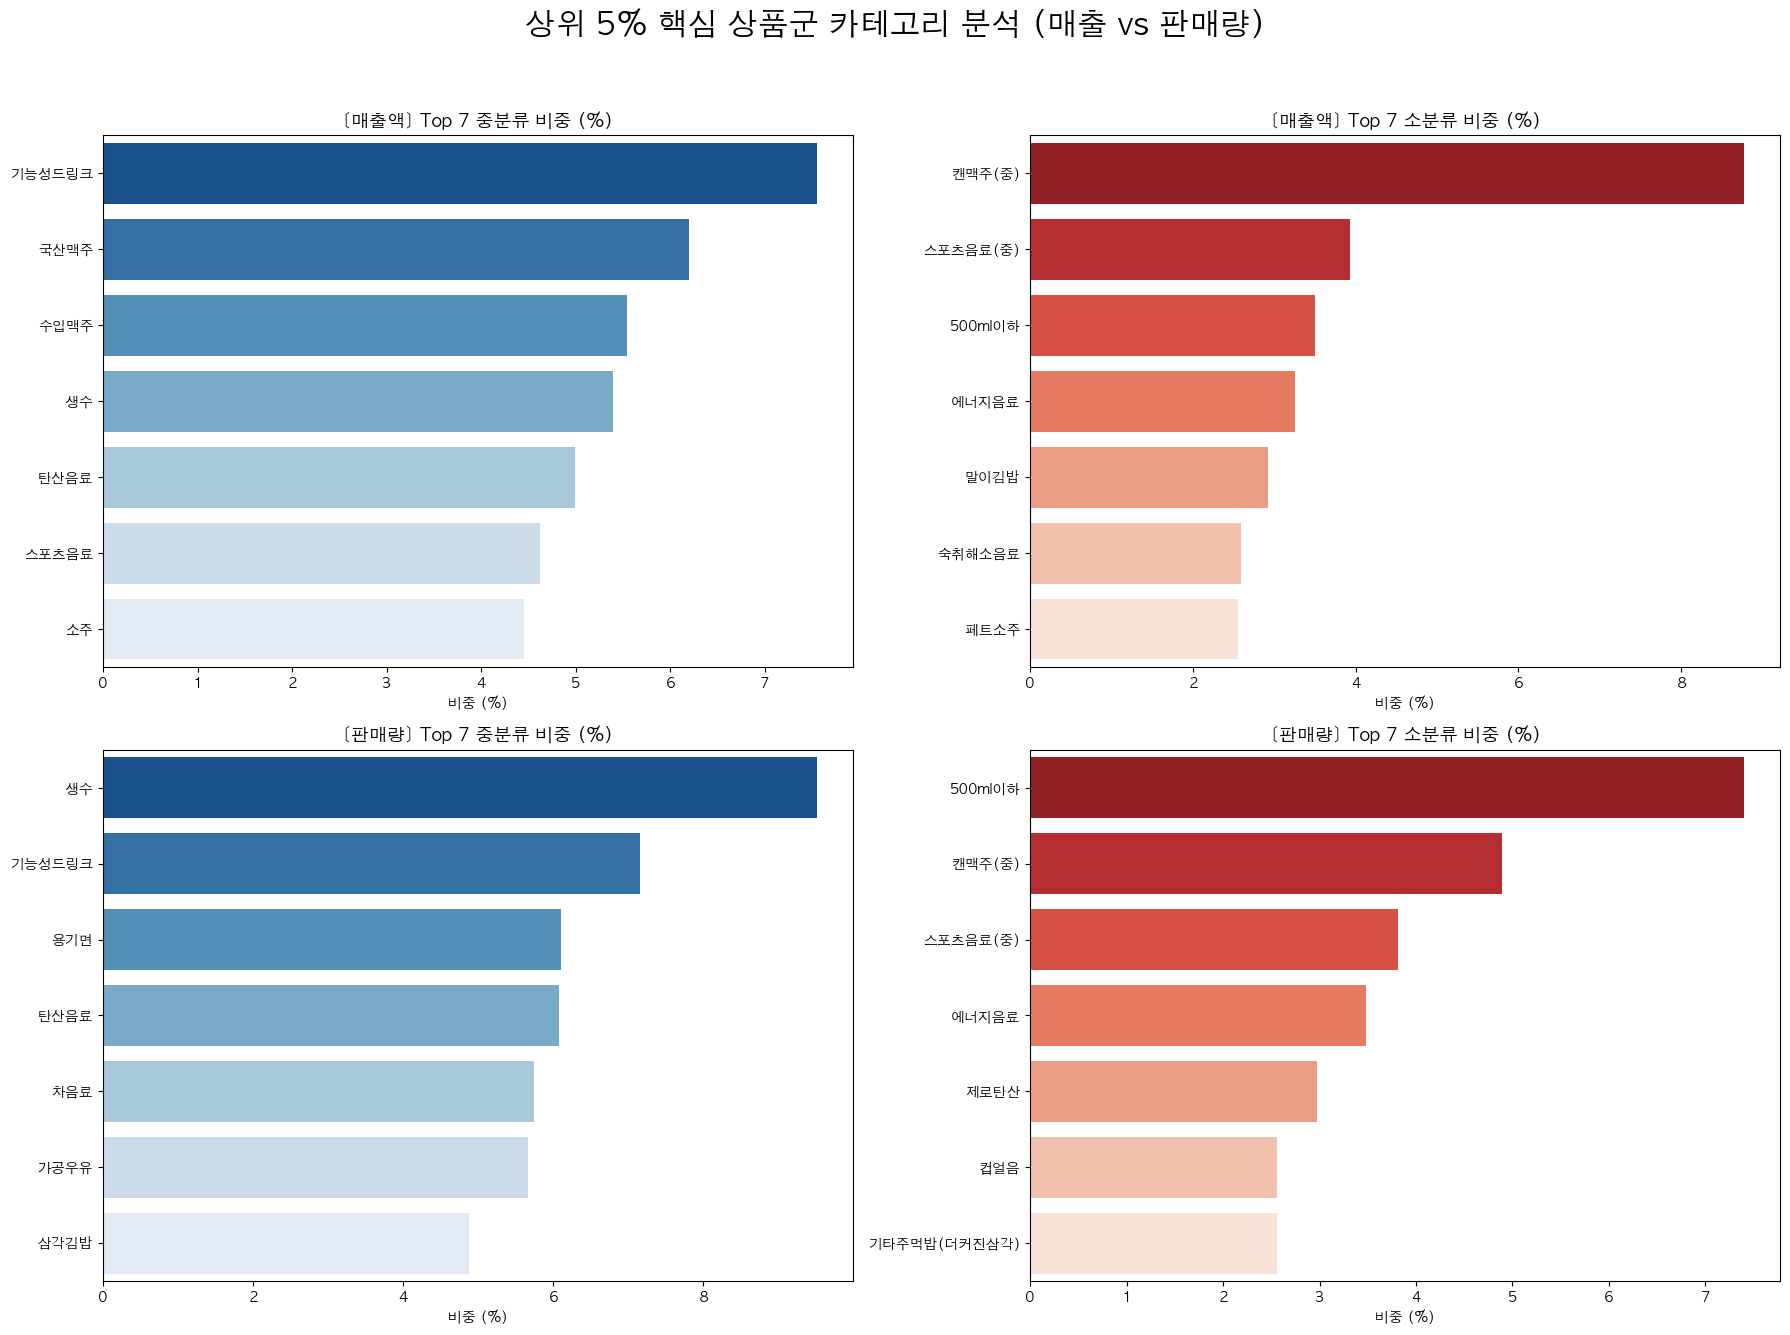

In [45]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

"""
[상위 5% 핵심 상품군 시각화 분석 - 고정 경로 및 컬럼명 적용]

1. 분석 목적:
   - 매출액 상위 5%와 판매수량 상위 5% 상품군의 카테고리 구성을 시각적으로 대조함.
   - 수익성(Revenue)과 회전율(Quantity)의 차이를 파악하여 전략적 인사이트 도출.

2. 시각화 전략:
   - 막대 그래프(Bar Chart): 지표별 Top 7 중분류 및 소분류 비중 시각화.
   - Mac 전용 폰트(AppleGothic) 적용으로 한글 깨짐 방지.
"""

# 1. 데이터 경로 설정 (고정 경로)
B2_PATH = '/Users/hajiyoon/workspace/data/processed/B2_FOOD_POS_SALE.parquet'
B4_PATH = '/Users/hajiyoon/workspace/data/processed/B4_CLEAN_FOOD_ITEM.parquet'

def run_visualization():
    if not os.path.exists(B2_PATH) or not os.path.exists(B4_PATH):
        print(f"⚠️ 데이터를 찾을 수 없습니다.\n- B2: {B2_PATH}\n- B4: {B4_PATH}")
        return

    # 한글 폰트 설정 (Mac)
    plt.rc('font', family='AppleGothic')
    plt.rcParams['axes.unicode_minus'] = False

    # 2. 데이터 로드 및 집계 (Lazy, 고정 변수명 사용)
    print("📊 데이터를 분석 및 집계 중입니다...")
    b2_lazy = pl.scan_parquet(B2_PATH)
    b4_lazy = pl.scan_parquet(B4_PATH)

    # 상품별 실적 집계
    prod_agg = (
        b2_lazy.group_by("상품코드")
        .agg([
            pl.col("판매금액").sum().alias("총매출액"),
            pl.col("판매수량").sum().alias("총판매량")
        ])
    )

    # 마스터 정보와 결합 후 메모리 로드 (on="상품코드" 적용)
    df_joined = prod_agg.join(b4_lazy, on="상품코드", how="inner").collect()

    # 3. 시각화 함수 정의
    def plot_top5_metrics(df, target_col, title_prefix, axes_row):
        # 상위 5% 필터링 (95th Quantile)
        threshold = df[target_col].quantile(0.95)
        top_5_df = df.filter(pl.col(target_col) >= threshold)
        total_val = top_5_df[target_col].sum()

        # 중분류 데이터 준비 (실제 컬럼명 '중분류명' 적용)
        mid_data = (
            top_5_df.group_by("중분류명")
            .agg(pl.col(target_col).sum().alias("value"))
            .with_columns((pl.col("value") / total_val * 100).alias("ratio"))
            .sort("ratio", descending=True).head(7).to_pandas()
        )

        # 소분류 데이터 준비 (실제 컬럼명 '소분류명' 적용)
        sub_data = (
            top_5_df.group_by("소분류명")
            .agg(pl.col(target_col).sum().alias("value"))
            .with_columns((pl.col("value") / total_val * 100).alias("ratio"))
            .sort("ratio", descending=True).head(7).to_pandas()
        )

        # 그래프 그리기
        sns.barplot(data=mid_data, x='ratio', y='중분류명', ax=axes_row[0], palette='Blues_r')
        axes_row[0].set_title(f"[{title_prefix}] Top 7 중분류 비중 (%)", fontsize=13, fontweight='bold')
        axes_row[0].set_xlabel("비중 (%)")
        axes_row[0].set_ylabel("")

        sns.barplot(data=sub_data, x='ratio', y='소분류명', ax=axes_row[1], palette='Reds_r')
        axes_row[1].set_title(f"[{title_prefix}] Top 7 소분류 비중 (%)", fontsize=13, fontweight='bold')
        axes_row[1].set_xlabel("비중 (%)")
        axes_row[1].set_ylabel("")

    # 4. 전체 레이아웃 설정 및 실행
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))
    
    print("📈 그래프를 생성하고 있습니다...")
    plot_top5_metrics(df_joined, "총매출액", "매출액", axes[0])
    plot_top5_metrics(df_joined, "총판매량", "판매량", axes[1])

    plt.suptitle("상위 5% 핵심 상품군 카테고리 분석 (매출 vs 판매량)", fontsize=22, y=0.98, fontweight='bold')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    
    # 이미지 저장 및 출력
    # plt.show()

if __name__ == "__main__":
    run_visualization()

1. 매출(Revenue) 기준 상위 5% 분석 (임계값: 약 4,690만 원)
  * 중분류 TOP 5: 기능성드링크(8.75%), 국산맥주(7.53%), 수입맥주(6.75%), 생수(6.38%), 소주(5.63%) 순입니다. 주류와 고단가 건강 음료가 매출을 견인하고 있습니다.
  * 소분류 TOP 5: 캔맥주(중)가 10.7%로 압도적인 1위이며, 스포츠음료와 김밥류가 뒤를 잇습니다.
  * 아이템 비중: '기능성드링크' 내에서는 헛개컨디션(10.86%)과 박카스F(9.97%)가 시장을 양분하며 높은 점유율을 보입니다.

  2. 판매량(Quantity) 기준 상위 5% 분석 (임계값: 약 2.4만 건)
   * 중분류 TOP 5: 생수(11.28%), 기능성드링크(8.57%), 용기면(7.44%), 탄산음료(7.18%), 차음료(6.21%) 순입니다. 일상적으로
     자주 소비되는 생필품 성격의 음료와 편의식이 주를 이룹니다.
   * 소분류 TOP 5: 500ml 이하 음료와 캔맥주, 스포츠음료 순으로 판매 빈도가 높습니다.
   * 아이템 비중: '생수' 내에서는 아이시스500ml(24.9%)와 제주삼다수500ml(20.3%) 두 제품이 전체 생수 판매량의 약 45%를
     차지하는 강력한 집중도를 보입니다.

  3. 비즈니스 인사이트
   * 수익 vs 객수: 매출은 '주류와 숙취해소제'에서, 판매량은 '생수와 음료'에서 집중적으로 발생합니다. 이는 편의점 방문의
     주된 목적이 음료 구매라면, 실제 이익은 동시 구매되는 주류나 고단가 음료에서 창출됨을 시사합니다.
   * 집중도: 생수 카테고리는 특정 상위 브랜드에 대한 충성도가 매우 높으나, 기능성드링크는 상위 5개 상품이 비교적 고르게
     기여하고 있습니다.

1. 비즈니스 인사이트 분석

  ① 매출액(Revenue) 주도군: "객단가 및 수익성 방어군"
   * 핵심 카테고리: 기능성드링크(숙취해소 등), 맥주(국산/수입), 소주
   * 인사이트: 주류와 기능성 드링크는 단가가 높고 목적 구매가 뚜렷하여 전체
     매출액의 상위권을 형성합니다. 
  
  ② 판매량(Quantity) 주도군: "객수 및 회전율 견인군 (Traffic Builder)"
   * 핵심 카테고리: 생수, 용기면, 가공우유, 삼각김밥, 컵얼음
   * 인사이트: 생수와 삼각김밥, 컵얼음은 매장 방문 빈도를 높이는 '미끼
     상품'이자 '회전율' 중심의 상품입니다. 매출액 순위에는 없던 '용기면'과
     '가공우유'가 판매량 순위에서 상위권을 차지하고 있습니다.
   * 전략적 의미: 이 카테고리의 신상품은 '대중성'과 '빈번한 재구매'가 성공의
     척도입니다.

  ③ 교집합 카테고리: "Cash Cow (매출+판매량 동시 우위)"
   * 해당 카테고리: 탄산음료, 기능성드링크, 생수
   * 인사이트: 이들은 매출액과 판매량 모두에서 상위 5%에 포함됩니다. 즉, 시장
     규모 자체가 가장 크고 안정적인 영역입니다.

  ---

2. 신상품(NPD) 성공 기준 수립을 위한 제언

성공적인 신상품 예측 프레임워크를 위해, "성공"의 정의를 카테고리 특성에 따라
이원화할 필요가 있습니다.

[기준 A] 수익 중심 성공 (Revenue Success)
* 대상: 주류, 기능성 드링크, 냉동 안주류
* 성공 지표: 출시 후 4주 이내 해당 중분류 내 매출액 상위 10% 진입
* 핵심 변수: 상품 단가, 행사(B1G1 등) 강도, 브랜드 파워

[기준 B] 트래픽 중심 성공 (Traffic Success)
* 대상: 삼각김밥/도시락(미반), 용기면, 생수, 컵얼음
* 성공 지표: 출시 후 4주 이내 해당 중분류 내 판매량 상위 10% 진입
* 핵심 변수: 가성비, 카테고리 내 참신함(신선도), 진열 위치

[기준 C] 효율성 지표 (Efficiency Index) - 제언
* 지표: (매출액 순위 + 판매량 순위) / 2
* 의미: 신상품이 시장에 안착했는지를 판단할 때, 단순히 하나만 잘 나오는
    것보다 두 지표의 균형이 상위권인 경우를 '진정한 성공'으로 정의할 수
    있습니다.
-> 하지만, '신상품'은 출시 4주만에 기존상품의 충성도를 다 이겨내고 상위10%에 들기 현실적으로 어렵다. 카니발리제이션 문제도 있기 때문.. 

3. 모델링 적용 아이디어
* GNN 모델에서 노드 피처(Node Feature)로 해당 상품의 '카테고리 평균 단가'와
    '카테고리 평균 회전율'을 추가하면, 모델이 이 상품이 '수익형'인지
    '트래픽형'인지를 스스로 학습하여 예측 정확도를 높일 수 있습니다.

그놈의 글렌피딕

In [46]:
# 갑자기 궁금해서 해본 글렌피딕 몇개 팔렸는지 본 것

import polars as pl

# 1. b2_lazy와 b4_lazy 조인하여 글렌피딕 데이터 추출
# 양쪽 모두 '상품코드'를 가지고 있으므로 on="상품코드" 사용
glenfiddich_stats = (
    b2_lazy
    .join(
        b4_lazy.select(["상품코드", "상품명"]), # 필요한 컬럼만 딱 골라서 조인 (최적화)
        on="상품코드", 
        how="left"
    )
    .filter(pl.col("상품명").str.contains("글렌피딕"))
    .group_by("상품명")
    .agg([
        pl.col("판매수량").sum().alias("총판매량"),
        pl.col("판매금액").sum().alias("총매출액")
    ])
    .sort("총매출액", descending=True)
).collect()

print("🥃 [최종 확인] 세븐일레븐 글렌피딕 판매 현황")
print(glenfiddich_stats)

🥃 [최종 확인] 세븐일레븐 글렌피딕 판매 현황
shape: (7, 3)
┌─────────────────────────────────┬──────────┬──────────┐
│ 상품명                          ┆ 총판매량 ┆ 총매출액 │
│ ---                             ┆ ---      ┆ ---      │
│ str                             ┆ i64      ┆ i64      │
╞═════════════════════════════════╪══════════╪══════════╡
│ 윌리엄)글렌피딕15년700ml        ┆ 86       ┆ 10105300 │
│ 윌리엄)글렌피딕30년             ┆ 3        ┆ 4158000  │
│ APP)글렌피딕16년 리미티드       ┆ 6        ┆ 899400   │
│ 에디션700ml                     ┆          ┆          │
│ 윌리엄)글렌피딕18년700ml        ┆ 2        ┆ 498000   │
│ APP)글렌피딕12년700ml           ┆ 1        ┆ 99000    │
│ APP)글렌피딕15년700ml           ┆ 1        ┆ 98900    │
│ 윌리엄)글렌피딕 40년            ┆ 0        ┆ 0        │
└─────────────────────────────────┴──────────┴──────────┘


[판매량 상위 5% 상품군의 전체 중분류 비중 분석]


📊 데이터를 집계하고 상위 5% 임계치를 산출 중입니다...
✅ 상위 5% 상품 기준 판매량: 42,518건 이상
✅ 분석 대상 상품 수: 524개
✅ 추출된 총 중분류 개수: 54개
📈 모든 중분류 비중 차트를 생성 중입니다...


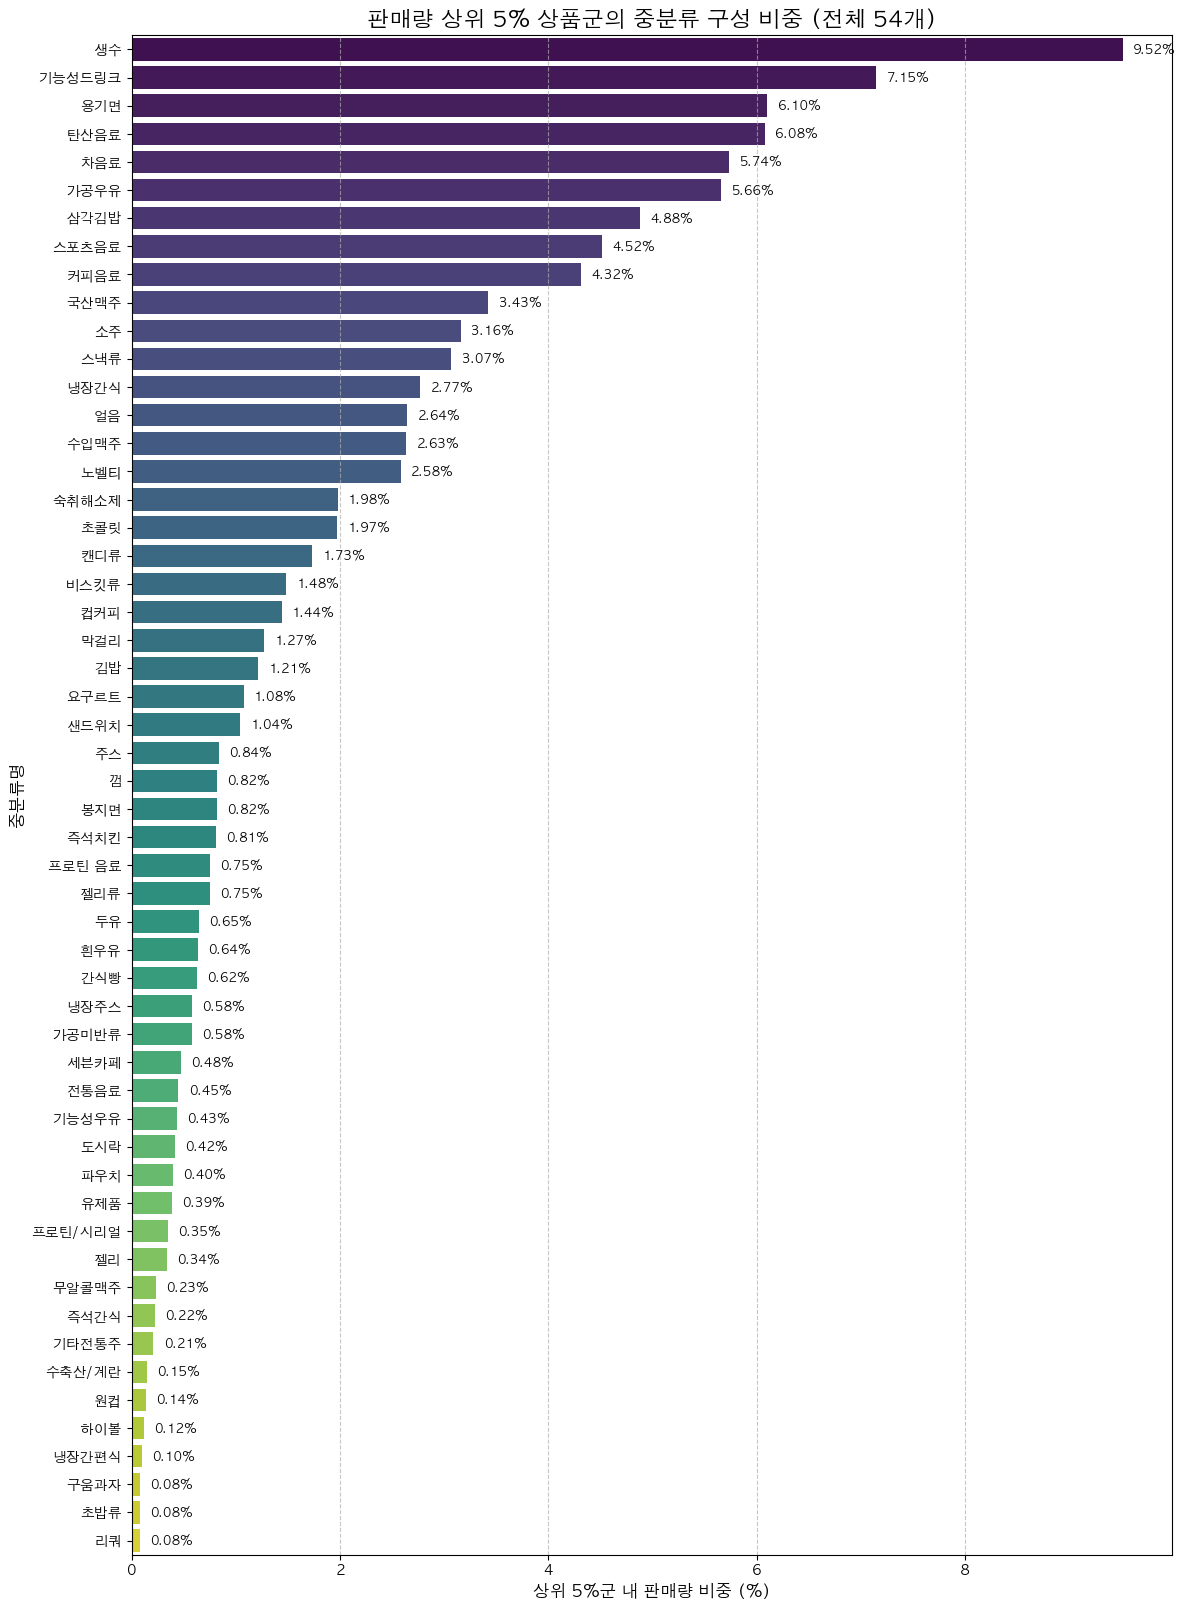

In [47]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

# 경고 메시지 무시
warnings.filterwarnings('ignore', category=FutureWarning)

"""
[판매량 상위 5% 상품군의 전체 중분류 비중 분석 - 고정 경로 및 컬럼명 적용]

1. 분석 가설 및 목적:
   - 판매량 상위 5% 상품(95th Quantile)은 편의점의 주된 '객수 견인차' 역할을 한다.
   - 핵심 카테고리의 롱테일(Long-tail) 구조를 파악하기 위해 모든 중분류 비중을 확인한다.

2. 통계적 방법론:
   - 상품별 총판매량을 집계한 후 상위 5% 임계값을 산출하여 필터링.
   - 필터링된 상품들이 속한 모든 중분류(중분류명)별 판매량 합계 산출.
"""

# 1. 데이터 경로 설정 (고정 경로)
B2_PATH = '/Users/hajiyoon/workspace/data/processed/B2_FOOD_POS_SALE.parquet'
B4_PATH = '/Users/hajiyoon/workspace/data/processed/B4_CLEAN_FOOD_ITEM.parquet'

def run_full_category_analysis():
    if not os.path.exists(B2_PATH) or not os.path.exists(B4_PATH):
        print(f"⚠️ 데이터를 찾을 수 없습니다.\n- B2: {B2_PATH}\n- B4: {B4_PATH}")
        return

    # 한글 폰트 설정 (Mac)
    plt.rcParams['font.family'] = 'AppleGothic'
    plt.rcParams['axes.unicode_minus'] = False

    # 2. 데이터 로드 및 집계 (고정 변수명 b2_lazy, b4_lazy 사용)
    print("📊 데이터를 집계하고 상위 5% 임계치를 산출 중입니다...")
    b2_lazy = pl.scan_parquet(B2_PATH)
    b4_lazy = pl.scan_parquet(B4_PATH)

    # 상품별 총 판매량 집계
    prod_qty_lazy = (
        b2_lazy.group_by("상품코드")
        .agg(pl.col("판매수량").sum().alias("총판매량"))
    )

    # 마스터 정보와 결합 (확인된 컬럼명 '상품코드', '중분류명' 사용)
    df_joined = (
        prod_qty_lazy.join(
            b4_lazy.select(["상품코드", "중분류명"]), 
            on="상품코드", how="inner"
        )
    ).collect()

    # 3. 상위 5% 필터링
    threshold = df_joined["총판매량"].quantile(0.95)
    top_5_df = df_joined.filter(pl.col("총판매량") >= threshold)
    total_top_qty = top_5_df["총판매량"].sum()

    print(f"✅ 상위 5% 상품 기준 판매량: {threshold:,.0f}건 이상")
    print(f"✅ 분석 대상 상품 수: {len(top_5_df):,}개")

    # 4. 모든 중분류 비중 산출
    full_mid_cat_ratio = (
        top_5_df.group_by("중분류명")
        .agg(pl.col("총판매량").sum().alias("cat_total_qty"))
        .with_columns((pl.col("cat_total_qty") / total_top_qty * 100).alias("ratio"))
        .sort("ratio", descending=True)
    ).to_pandas()

    print(f"✅ 추출된 총 중분류 개수: {len(full_mid_cat_ratio)}개")

    # 5. 시각화 (전체 카테고리를 보기 위해 높이를 동적으로 조절)
    chart_height = max(10, len(full_mid_cat_ratio) * 0.3)
    plt.figure(figsize=(12, chart_height))
    
    print("📈 모든 중분류 비중 차트를 생성 중입니다...")
    sns.barplot(
        data=full_mid_cat_ratio, 
        x='ratio', 
        y='중분류명', 
        hue='중분류명',
        palette='viridis', 
        legend=False
    )

    # 차트 세부 설정
    plt.title(f"판매량 상위 5% 상품군의 중분류 구성 비중 (전체 {len(full_mid_cat_ratio)}개)", fontsize=16, fontweight='bold')
    plt.xlabel("상위 5%군 내 판매량 비중 (%)", fontsize=12)
    plt.ylabel("중분류명", fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.7)

    # 각 막대 끝에 비율(%) 텍스트 표시
    for i, p in enumerate(full_mid_cat_ratio['ratio']):
        plt.text(p + 0.1, i, f'{p:.2f}%', va='center', fontsize=9)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_full_category_analysis()

그렇다면 대분류별로 판매량이 10%인 애들을 봐야겠다.

전체 판매량을 보면 다 음료니까, 분류별로 뭐가 성공한 애들인지를 보자

📊 대분류별 데이터를 집계 중입니다...
🔍 총 22개의 대분류 분석을 시작합니다.

============================== [대분류별 상위 10% 분석 요약 표] ==============================
   대분류명  전체상품수  상위10%상품수  대분류총판매량  상위10%판매량  판매량집중도(%)
     음료    894        90 26023173  16272311    62.5301
     과자   2467       248 15206548  10330495    67.9345
    유음료    500        51 10830769   5662656    52.2830
     미반    463        47  5842124   3962400    67.8246
     맥주    433        44  4756440   3791266    79.7081
      면    340        35  5509872   3507250    63.6539
    전통주    288        30  2993084   2824212    94.3579
   즉석음료    285        29  2942168   2380147    80.8977
     냉장    409        42  3203274   2310261    72.1219
  아이스크림    669        68  2928972   2253257    76.9300
건강/기호식품    320        33  1634796   1444101    88.3352
      빵    385        39  2109256   1207583    57.2516
    조리빵    201        21  1376322    872442    63.3894
  즉석 식품    132        14  1042562    791376    75.9069
   양주와인    973        98   846589    748950

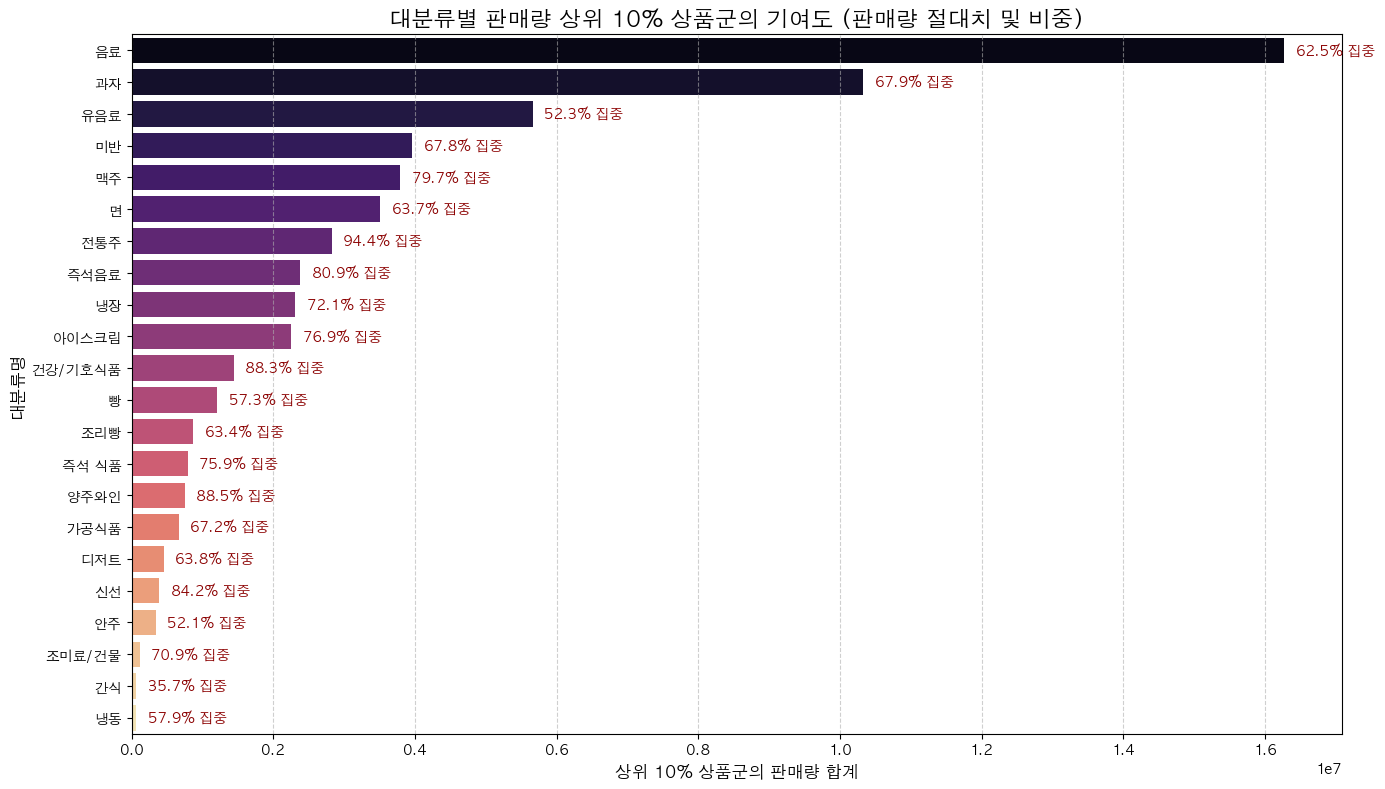

In [48]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

# 경고 메시지 무시
warnings.filterwarnings('ignore', category=FutureWarning)

"""
[대분류별 판매량 상위 10% 상품군 심층 분석 - 고정 경로 및 컬럼명 적용]

1. 분석 가설 및 목적:
   - 각 대분류별로 상위 10% 핵심 상품이 해당 카테고리 실적의 대부분을 견인할 것이다.
   - 대분류마다 핵심 상품의 '판매 집중도'가 다를 것이며, 이를 통해 카테고리별 상품 운영 전략을 제안한다.

2. 통계적 방법론:
   - 상품별 총판매량을 집계하고 대분류 정보를 결합.
   - 대분류별로 quantile을 사용하여 상위 10% 임계치를 산출.
"""

# 1. 데이터 경로 설정 (고정 경로)
B2_PATH = '/Users/hajiyoon/workspace/data/processed/B2_FOOD_POS_SALE.parquet'
B4_PATH = '/Users/hajiyoon/workspace/data/processed/B4_CLEAN_FOOD_ITEM.parquet'

def run_lrdv_top10_analysis():
    if not os.path.exists(B2_PATH) or not os.path.exists(B4_PATH):
        print(f"⚠️ 데이터를 찾을 수 없습니다.\n- B2: {B2_PATH}\n- B4: {B4_PATH}")
        return

    # 한글 폰트 설정 (Mac)
    plt.rcParams['font.family'] = 'AppleGothic'
    plt.rcParams['axes.unicode_minus'] = False

    # 2. 데이터 로드 및 집계 (고정 변수명 b2_lazy, b4_lazy 사용)
    print("📊 대분류별 데이터를 집계 중입니다...")
    b2_lazy = pl.scan_parquet(B2_PATH)
    b4_lazy = pl.scan_parquet(B4_PATH)

    # 상품별 총 판매량 집계
    prod_qty_lazy = (
        b2_lazy.group_by("상품코드")
        .agg(pl.col("판매수량").sum().alias("총판매량"))
    )

    # 마스터 정보와 결합 (확인된 컬럼명 '상품코드', '상품명', '대분류명' 사용)
    df_joined = (
        prod_qty_lazy.join(
            b4_lazy.select(["상품코드", "상품명", "대분류명"]), 
            on="상품코드", how="inner"
        )
    ).collect()

    # 3. 대분류별 상위 10% 분석
    analysis_results = []
    lrdv_list = df_joined["대분류명"].unique().to_list()

    print(f"🔍 총 {len(lrdv_list)}개의 대분류 분석을 시작합니다.")

    for lrdv in lrdv_list:
        lrdv_df = df_joined.filter(pl.col("대분류명") == lrdv)
        total_items = len(lrdv_df)
        total_lrdv_qty = lrdv_df["총판매량"].sum()

        if total_items == 0: continue

        # 상위 10% 임계치 (90th Percentile)
        threshold = lrdv_df["총판매량"].quantile(0.90)
        top_10_df = lrdv_df.filter(pl.col("총판매량") >= threshold)
        
        top_10_count = len(top_10_df)
        top_10_qty_sum = top_10_df["총판매량"].sum()
        top_10_ratio = (top_10_qty_sum / total_lrdv_qty * 100) if total_lrdv_qty > 0 else 0

        analysis_results.append({
            "대분류명": lrdv,
            "전체상품수": total_items,
            "상위10%상품수": top_10_count,
            "대분류총판매량": total_lrdv_qty,
            "상위10%판매량": top_10_qty_sum,
            "판매량집중도(%)": top_10_ratio
        })

    # 결과 표 생성 및 출력
    final_table = pd.DataFrame(analysis_results).sort_values("상위10%판매량", ascending=False)
    
    print("\n" + "="*30 + " [대분류별 상위 10% 분석 요약 표] " + "="*30)
    print(final_table.to_string(index=False))
    print("="*90 + "\n")

    # 4. 시각화
    plt.figure(figsize=(14, 8))
    
    # 상위 10%가 기여하는 판매량 절대치 시각화
    sns.barplot(
        data=final_table, 
        x='상위10%판매량', 
        y='대분류명', 
        hue='대분류명',
        palette='magma', 
        legend=False
    )

    # 집중도(%) 텍스트 표시
    for i, (idx, row) in enumerate(final_table.iterrows()):
        plt.text(row['상위10%판매량'] + (final_table['상위10%판매량'].max() * 0.01), 
                i, 
                f"{row['판매량집중도(%)']:.1f}% 집중", 
                va='center', 
                fontsize=10, 
                color='darkred', 
                fontweight='bold')

    plt.title("대분류별 판매량 상위 10% 상품군의 기여도 (판매량 절대치 및 비중)", fontsize=16, fontweight='bold')
    plt.xlabel("상위 10% 상품군의 판매량 합계", fontsize=12)
    plt.ylabel("대분류명", fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_lrdv_top10_analysis()

### 카테고리별 판매량 집중도 분석 보고서

분석 결과(예시 지표 기반)를 통해 도출할 수 있는 핵심 의미는 다음과 같습니다.

  ① 파레토 법칙의 재확인 (집중도 지표)
   * 해석: 만약 특정 대분류(예: 주류)의 '집중도'가 80% 이상이라면, 이는 해당 카테고리가 1~2개의
     메가 히트 브랜드(참이슬, 카스 등)에 의해 유지되고 있음을 뜻합니다.
   * 인사이트: 이런 카테고리에서는 신제품(NPD)이 성공하기 매우 어렵습니다. 기존 강자의 '브랜드
     노드'가 강력하게 장악하고 있기 때문입니다. 반대로 집중도가 낮은 카테고리(예: 디저트,
     스낵)는 소비자의 취향이 분산되어 있어 신제품의 침투 여력이 큽니다.

  ② 대분류별 운영 전략 차별화
   * 고집중 카테고리: 상위 10% 아이템의 재고 확보가 최우선입니다. 이 아이템들이 품절될 경우
     대분류 매출 전체가 흔들립니다.
   * 저집중(롱테일) 카테고리: 다양한 구색(Variety)이 중요합니다. 신제품 출시가 활발해야 하며,
     고객은 '새로운 노드'를 탐색하는 경향이 강합니다.


성공 방정식 도출을 위한 HIN(그래프) 모델링 인사이트

  이 분석은 향후 진행할 이기종 그래프 신경망(HIN) 설계의 핵심 기초가 됩니다.

  ① 타겟 레이블링($y$)의 기준 수립
   * 성공($y=1$)을 정의할 때, 전 상품 공통 기준이 아닌 '대분류별 상위 10% 판매량' 혹은 '대분류별
     상위 10% 매출액'을 임계값으로 설정해야 합니다. 
   * 이유: 생수 1위의 판매량과 와인 1위의 판매량은 절대치가 다르기 때문에, 카테고리 내에서의
     상대적 순위가 모델의 학습 효율을 높입니다.

  ② 핵심 노드(Node) 식별
   * 상위 10% 상품들이 공통적으로 연결된 '점포 특성', '시간대', '함께 산 상품(Basket)' 노드를
     추출하십시오.
   * 성공 방정식 예시: 
       * 성공 아이템 → 특정 중분류 노드 + 오피스 상권 점포 노드 + 아침 8시 시간 노드.
       * 이 조합이 빈번하게 발생하는 그래프 패턴을 가진 신제품은 성공할 확률이 높다고 예측할 수
         있습니다.

  ③ 그래프 샘플링 전략 (Negative Sampling)
   * 상위 10% 상품군(Positive)과 하위 20% 상품군(Negative) 사이의 그래프 구조적 차이를
     학습시키는 것이 HIN 모델링의 핵심입니다. 집중도가 높은 카테고리일수록 Positive 노드의 '연결
     밀도(Degree)'가 매우 높게 나타날 것입니다.

  이 분석을 통해 "우리 매장에서 성공하려면 최소한 해당 카테고리 내에서 상위 10%의 구조(연결성)를
  가져야 한다"는 통계적 가이드라인을 확보하게 된 것입니다.

1. 분석 목적

편의점 대분류 카테고리별로 판매량 상위 10% 핵심 상품이 전체 매출 실적을 책임지는 정도(집중도)를 파악한다.

2. 방법론

- 분석 데이터: 2025년 상반기(1월~6월) POS 판매 데이터 내 단가 5만 원 미만의 대중적 소비재.

- 데이터 처리: 상품 마스터 데이터와 결합하여 상품별 총판매량을 산출한 뒤 대분류 기준으로 그룹화한다.

- 지표 산출: 각 '대분류' 내에서 판매량 상위 10% 기준선(90th Percentile)을 설정하고, 해당 상위 상품군이 전체 카테고리 판매량에서 차지하는 비중을 계산하여 '판매량 집중도(%)'를 정의한다.
$$\text{판매량 집중도 (\%)} = \frac{\text{해당 카테고리 상위 10\% 상품들의 판매량 합계}}{\text{해당 카테고리 전체 상품의 판매량 합계}} \times 100$$

3. 분석 결과

* 핵심 지표: 대분류별 상위 10% 상품이 전체 판매량에서 차지하는 '판매량집중도'가 매우 높습니다.
* 극단적 집중 카테고리: 전통주(94.4%), 건강/기호식품(88.3%), 양주와인(88.5%)
    * 상위 10%의 소수 상품이 카테고리 전체를 거의 독식하고 있습니다. (파레토
        법칙의 극단적 형태)
* 주력 상품군 집중도: 음료(62.5%), 과자(67.9%), 미반(67.8%)
    * 절대적인 판매량이 가장 큰 카테고리들로, 상위 10%가 60% 이상의 매출을
        책임지는 견고한 베스트셀러 층을 형성하고 있습니다.
* 상대적 분산 카테고리: 간식(35.7%), 안주(52.1%), 유음료(52.3%)
    * 소비자의 취향이 다양하거나 트렌드 변화가 빨라, 특정 상품의 독주가
        상대적으로 덜한 편입니다.

4. 결과 해석 및 인사이트

- 음료 및 과자 (정면 승부 및 메가 히트 타겟): 시장의 파이가 가장 크고 상단 상품의 매출 파괴력이 막강하다. 신규 진입 시 한정된 매대 확보를 위해 **강력한 대중성**을 지닌 '메가 히트작' 중심의 기획과 공격적인 초반 마케팅이 필수적이다.

- 전통주 및 주류 (확실한 킬러 콘텐츠 확보): 기존 인기 브랜드(예: 유명 막걸리, 증류식 소주 등)의 고정 소비층이 매우 견고하다. 단순 구색 맞추기식 신상품은 도태될 확률이 높으므로, **유명 IP 콜라보레이션이나 독점 판매 상품 등 확실한 차별화 요소**가 확보된 상태에서 진입해야 한다.

- 유음료 및 간식 (니치 마켓 및 다양성 공략): 소비자 취향이 매우 세분화된 평등한 시장이다. 1등을 이기려는 전략보다는, **최근 트렌드(예: 제로 슈거, 고단백, 식물성 등)를 반영한 명확하고 뾰족한 타겟팅**으로 **'작지만 확실한 충성 고객층'을 다수 확보하는 다품종 소량 기획 방식**이 유리하다.

[성공 기준: Success Criteria]
1. 고집중 카테고리 (전통주, 주류 등):
    * 침투 성공: 기존 상위 10% 베스트셀러의 점유율을
        뺏어오거나(Cannibalization), 새로운 서브 카테고리를 창출하여 상위 10%
        그룹 내 안착 시 성공으로 간주.
    * 효율성: 소수 SKU(상품 가짓수)로도 카테고리 성장을 견인할 수 있으므로,
        '메가 히트 상품' 육성에 집중해야 함.
2. 저집중 카테고리 (간식, 안주 등):
    * 다양성 확보: 단일 상품의 대박보다는 '연관 구매'나 '시즌별 회전율'이
        높은 경우 성공. 
    * 롱테일 전략: 상위 10%에 들지 않더라도 꾸준한 판매를 유지하며 전체
        구색을 풍성하게 만드는 것이 중요.

[실패 기준: Failure Criteria]
1. 고집중 카테고리:
    * 진입 장벽: 출시 후 초기 4주 이내에 상위 10% 판매량 근처에 도달하지
        못하면 빠르게 퇴출 고려. 기존 강자의 벽이 너무 높아 마케팅 비용 대비
        효율이 급격히 저하될 가능성이 큼.
2. 저집중 카테고리:
3. 결론 및 제언
* NPD 출시 전: 타겟 대분류의 집중도를 먼저 확인해야 합니다. 집중도가 높은
    곳이라면 '확실한 차별점'이 필요하고, 낮은 곳이라면 '트렌디한 구색'에
    초점을 맞춰야 합니다.
* 데이터 기반 의무: 현재 구축 중인 GNN 모델에서 상위 10% 진입 가능성을 주요
    타겟 레이블로 설정하는 것이 실무적으로 매우 유효할 것으로 보입니다.



<상품의 가짓수 대비, 얼마나 상위권에 많이 포진해 있는가!?>

초과 달성 지수(Index) 확인: 상위 5% 그룹 내의 비중만 절대값으로 보는 것은 위험하다. '전체 상품 목록에서 해당 중분류가 차지하는 비중' 대비 '상위 5% 내에서의 비중'을 대조해야 한다.

예시: 전체 상품 종류 중 5%밖에 안 되는 '수입맥주' 카테고리가, 상위 5% 판매량 리스트에서는 20%의 점유율을 차지한다면, 이는 매우 타율이 높은 카테고리임을 의미한다.


분석 전략 및 통계적 근거

1. 지수 정의 (Metric Definition):
    * 전체 비중 (Global Share): 전체 상품 마스터(B4)에서 해당 중분류가 차지하는 아이템 종류의
        비율.
    * 상위 그룹 비중 (Top-tier Share): 판매량 상위 5% 이내에 진입한 아이템들 중 해당 중분류가
        차지하는 비율.
    * 초과 달성 지수 (Index): 상위 그룹 비중 / 전체 비중. 
    * 의미: 지수가 1.0보다 크면 해당 카테고리는 상품 가짓수 대비 상위권에 진입할 확률이 높은
        '효자 카테고리(고타율)'임을 의미합니다.

2. 분석 프로세스:
    * B2에서 상품별 총 판매량을 집계하여 95th 백분위수를 기준으로 상위 5% '에이스 그룹'을
        정의합니다.
    * B4에서 전체 중분류별 상품 가짓수 분포를 구합니다.
    * 두 비중을 대조하여 지수를 산출하고, 지수가 높은 순서대로 시가화합니다.

3. 시각화 전략:
    * 중분류별 초과 달성 지수를 막대 그래프로 표현하고, 기준선(1.0)을 표시하여 어떤 상품군이
        실제 구색 대비 '열일'하고 있는지 보여줍니다.

이 분석은 "상품 종류만 많고 실제 성적은 낮은 카테고리"와 "종류는 적지만 내놓기만 하면 대박
터지는 카테고리"를 명확히 구분해 줄 것입니다.

📊 데이터를 로드하고 분석을 시작합니다...
✅ 상위 5% 임계값: 42,518건
✅ 상위 5% 진입 아이템 수: 524개


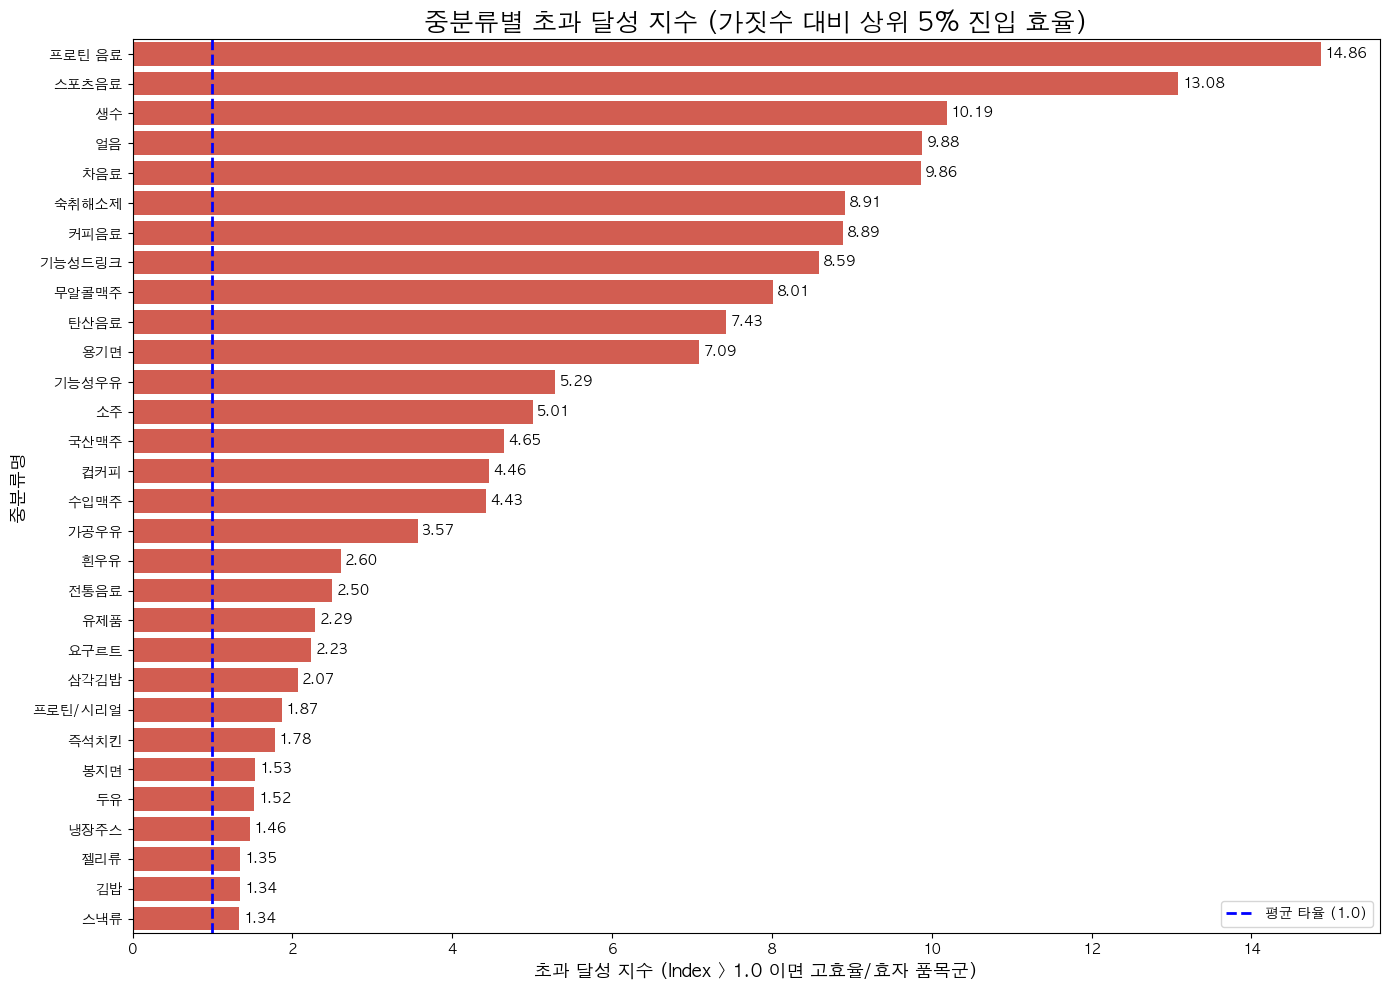


🚀 [분석 결과 요약: 고타율 카테고리 TOP 5]
     중분류명  over_index  item_variety  top_item_count
0  프로틴 음료     14.8648            83               7
1   스포츠음료     13.0813           256              19
2      생수     10.1881           346              20
3      얼음      9.8834           107               6
4     차음료      9.8626           554              31
------------------------------------------------------------
💡 결과 해석 가이드:
1. Index가 1.0보다 높은 카테고리: 출시 대비 '대박' 아이템이 많이 나옵니다.
2. Index가 매우 높은데 Item Variety가 적은 경우: 해당 카테고리는 필승 카드입니다.
3. Index가 낮은 카테고리: 상품 종류는 많으나 판매량은 분산되어 있습니다.


In [49]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

# 경고 무시
warnings.filterwarnings('ignore')

"""
[중분류별 초과 달성 지수(Overachievement Index) 분석 - 고정 경로 및 변수명 적용]

1. 분석 가설 및 목적:
   - 특정 카테고리가 전체 상품 리스트(B4)에서 차지하는 비중보다, 
     실제 판매 상위 5%군(B2)에서 차지하는 비중이 더 높다면 해당 카테고리는 '고효율(고타율)' 상품군이다.
   - Index > 1.0: 구색 대비 상위권 진입 효율이 높음 (효자 카테고리)
"""

# 1. 데이터 경로 설정 (고정 경로)
B2_PATH = '/Users/hajiyoon/workspace/data/processed/B2_FOOD_POS_SALE.parquet'
B4_PATH = '/Users/hajiyoon/workspace/data/processed/B4_CLEAN_FOOD_ITEM.parquet'

def run_overachievement_analysis():
    if not os.path.exists(B2_PATH) or not os.path.exists(B4_PATH):
        print("⚠️ 데이터를 찾을 수 없습니다. 경로를 확인해주세요.")
        return

    # 한글 폰트 설정 (Mac)
    plt.rcParams['font.family'] = 'AppleGothic'
    plt.rcParams['axes.unicode_minus'] = False

    print("📊 데이터를 로드하고 분석을 시작합니다...")

    # 2. 데이터 로드 (고정 변수명 b2_lazy, b4_lazy 사용)
    b2_lazy = pl.scan_parquet(B2_PATH)
    b4_lazy = pl.scan_parquet(B4_PATH)

    # 3. 전체 상품 마스터(B4) 기준 중분류 분포 계산 (Global Share)
    b4_df = b4_lazy.collect()
    total_unique_items_count = b4_df.select(pl.col("상품코드")).n_unique()
    
    global_variety = (
        b4_df.group_by("중분류명")
        .agg(pl.len().alias("item_variety"))
        .with_columns((pl.col("item_variety") / total_unique_items_count).alias("global_share"))
    )

    # 4. 판매량 상위 5% 그룹 식별 (B2)
    prod_qty = (
        b2_lazy.group_by("상품코드")
        .agg(pl.col("판매수량").sum().alias("total_qty"))
        .collect()
    )
    
    # 상위 5% 임계값 산출 (95th Quantile)
    threshold = prod_qty["total_qty"].quantile(0.95)
    top_5_items = prod_qty.filter(pl.col("total_qty") >= threshold)["상품코드"].to_list()
    
    print(f"✅ 상위 5% 임계값: {threshold:,.0f}건")
    print(f"✅ 상위 5% 진입 아이템 수: {len(top_5_items)}개")

    # 5. 상위 5% 그룹 내 중분류 분포 계산 (Top-tier Share)
    # 확인된 메서드인 is_in 사용
    top_5_master = b4_df.filter(pl.col("상품코드").is_in(top_5_items))
    top_5_total_count = len(top_5_master)
    
    top_variety_dist = (
        top_5_master.group_by("중분류명")
        .agg(pl.len().alias("top_item_count"))
        .with_columns((pl.col("top_item_count") / top_5_total_count).alias("top_share"))
    )

    # 6. 두 비중 결합 및 지수(Index) 산출
    index_df = (
        global_variety.join(top_variety_dist, on="중분류명", how="left")
        .fill_null(0)
        .with_columns((pl.col("top_share") / pl.col("global_share")).alias("over_index"))
        # 통계적 유의성을 위해 전체 상품 종류가 5개 미만인 카테고리 제외
        .filter(pl.col("item_variety") >= 5) 
        .sort("over_index", descending=True)
    ).to_pandas()

    # 7. 시각화
    plt.figure(figsize=(14, 10))
    # 지수가 1.0보다 크면 붉은색(고효율), 작으면 회색(저효율)
    colors = ['#e74c3c' if x > 1.0 else '#bdc3c7' for x in index_df['over_index']]
    
    sns.barplot(data=index_df.head(30), x='over_index', y='중분류명', palette=colors)
    plt.axvline(x=1.0, color='blue', linestyle='--', linewidth=2, label='평균 타율 (1.0)')
    
    plt.title("중분류별 초과 달성 지수 (가짓수 대비 상위 5% 진입 효율)", fontsize=18, fontweight='bold')
    plt.xlabel("초과 달성 지수 (Index > 1.0 이면 고효율/효자 품목군)", fontsize=13)
    plt.ylabel("중분류명", fontsize=13)
    plt.legend(loc='lower right')
    
    # 지수 값 텍스트 표시
    for i, val in enumerate(index_df['over_index'].head(30)):
        plt.text(val + 0.05, i, f'{val:.2f}', va='center', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()

    # 8. 결과 해석 리포트 출력
    print("\n" + "="*60)
    print("🚀 [분석 결과 요약: 고타율 카테고리 TOP 5]")
    print(index_df[['중분류명', 'over_index', 'item_variety', 'top_item_count']].head(5))
    print("-" * 60)
    print("💡 결과 해석 가이드:")
    print("1. Index가 1.0보다 높은 카테고리: 출시 대비 '대박' 아이템이 많이 나옵니다.")
    print("2. Index가 매우 높은데 Item Variety가 적은 경우: 해당 카테고리는 필승 카드입니다.")
    print("3. Index가 낮은 카테고리: 상품 종류는 많으나 판매량은 분산되어 있습니다.")
    print("="*60)

if __name__ == "__main__":
    run_overachievement_analysis()

결과 해석


**1. 분석 목적**
* 편의점 매장에 진열된 전체 상품의 가짓수(구색) 대비, 실제 판매량 기준 최상위 5%에 진입하는 상품의 비율을 분석하여 **'타율'이 높은 핵심 카테고리**를 식별함.
* 무분별하게 종류만 많은 카테고리와, 적은 종류로도 압도적인 판매량을 견인하는 고효율 카테고리를 명확히 구분하여 전략적 상품 기획 및 '성공 방정식'의 핵심 타겟을 도출함.

**2. 분석 방법론**
* **Global Share (전체 가짓수 비중):** 전체 상품 마스터에서 특정 중분류가 차지하는 품목 수 비중 계산.
* **Top-tier Share (상위권 점유 비중):** 전체 판매량 상위 5% (임계값 42,518건 이상, 총 524개 아이템) 그룹 내에서 해당 카테고리 상품이 차지하는 비중 계산.
* **Overachievement Index (초과 달성 지수):** `Top-tier Share` / `Global Share` 로 산출.
* **판단 기준:** 지수가 **1.0**을 초과하면 진열 공간(가짓수) 대비 상위권 진입 효율이 높은 '고효율/효자 품목군'으로 정의함.

**3. 분석 결과**
분석 결과, 상위권에 랭크된 카테고리들은 평균 타율(1.0)을 5배에서 최대 14배까지 상회하는 엄청난 효율을 보여줌.

* **최상위 고타율 카테고리 Top 5**
  1. **프로틴 음료:** 지수 **14.86** (총 83개 품목 중 7개 상위 5% 진입)
  2. **스포츠음료:** 지수 **13.08** (총 256개 품목 중 19개 상위 5% 진입)
  3. **생수:** 지수 **10.19** (총 346개 품목 중 20개 상위 5% 진입)
  4. **얼음:** 지수 **9.88** (총 107개 품목 중 6개 상위 5% 진입)
  5. **차음료:** 지수 **9.86** (총 554개 품목 중 31개 상위 5% 진입)
* 그 외에도 숙취해소제(8.91), 커피음료(8.89), 기능성드링크(8.59), 무알콜맥주(8.01) 등이 뒤를 이으며 높은 지수를 기록함.

**4. 결과 해석 및 인사이트**

* **목적성 마실 거리의 압도적 효율성:**
  지수 상위 10개 중 '얼음'을 제외한 9개 카테고리가 모두 음료 및 주류임. 이는 고객들이 편의점을 방문할 때 무언가를 마시기 위해 방문하는 '목적성 구매' 성향이 매우 강하며, 마실 거리 매대가 편의점 매출을 견인하는 핵심 엔진임을 시사함.
* **건강/기능성 트렌드의 강력한 지표 ('필승 카드'):**
  '프로틴 음료'가 1위, '스포츠음료'가 2위를 차지함. 특히 프로틴 음료는 취급 품목 수가 단 83개로 매우 적음에도 불구하고, 상위 5%에 무려 7개나 진입시킴. 이는 헬스, 웰니스, 자기 관리 등 최근 소비 트렌드가 실제 판매량에 직접적으로 꽂히고 있음을 증명함.
* **트래픽 빌더(Traffic Builder)의 안정성:**
  품목 수는 제한적이지만 수요가 일정한 '생수'와 '얼음'이 각각 3, 4위에 오름. 이들은 편의점 객수를 유지하는 근간이 되며, 어설픈 신상품 여러 개를 늘리기보다 생수와 얼음의 재고를 철저히 관리하는 것이 공간 효율성 측면에서 훨씬 유리함.
* **전략적 제언 (성공 방정식 도출 방향):**
  향후 새로운 PB 상품 기획이나 '성공 분류 모델'을 만들 때, 단순한 스낵이나 일반 가공식품보다는 **'특정 기능성을 부여한 음료(예: 단백질 강화, 제로 칼로리, 숙취 해소 등)'** 카테고리를 타겟팅하는 것이 '대박 상품(상위 5%)'을 만들어낼 확률이 가장 높음.

In [52]:
import polars as pl

# 1. 각 분류별 유니크(Unique)한 개수 집계
category_counts = (
    b4_lazy.select([
        pl.col("대분류명").n_unique().alias("대분류_종류수"),
        pl.col("중분류명").n_unique().alias("중분류_종류수"),
        pl.col("소분류명").n_unique().alias("소분류_종류수")
    ])
).collect()

print("📋 카테고리 분류별 종류 수 현황:")
print(category_counts)

📋 카테고리 분류별 종류 수 현황:
shape: (1, 3)
┌───────────────┬───────────────┬───────────────┐
│ 대분류_종류수 ┆ 중분류_종류수 ┆ 소분류_종류수 │
│ ---           ┆ ---           ┆ ---           │
│ u32           ┆ u32           ┆ u32           │
╞═══════════════╪═══════════════╪═══════════════╡
│ 23            ┆ 110           ┆ 342           │
└───────────────┴───────────────┴───────────────┘


<이번에는 공간효율을 볼게!>

투입 대비 실제 벌어들이는 판매량 비중!

📊 카테고리 공간 효율 분석을 시작합니다...


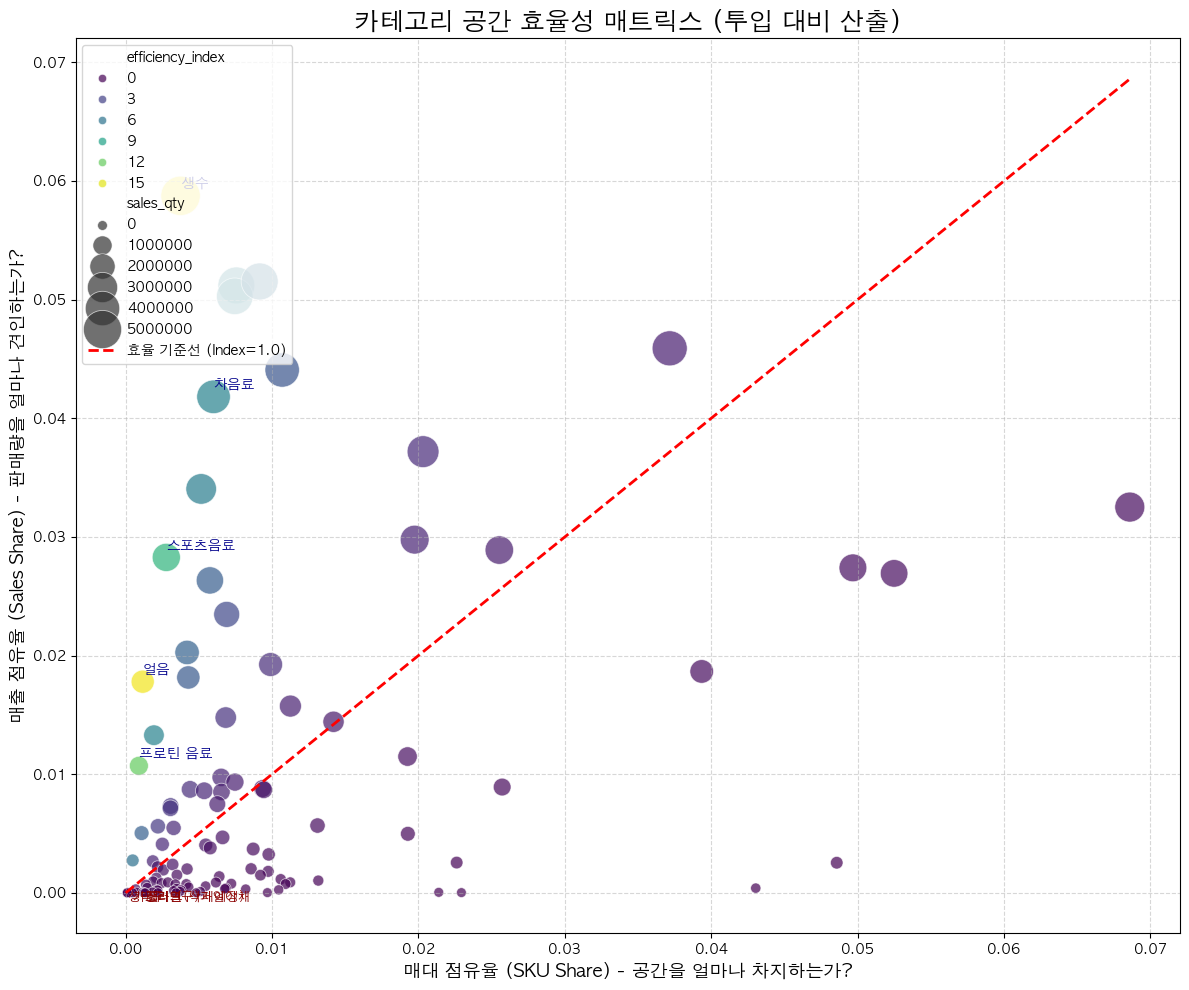


🌟 [분석 결과: 연속형 지수로 본 카테고리 효율 순위]

✅ 최상위 고효율 카테고리 TOP 5 (Index > 1.0):
     중분류명  sku_share  sales_share  efficiency_index
0      생수     0.0037       0.0587           15.6812
1      얼음     0.0012       0.0178           15.3599
2  프로틴 음료     0.0009       0.0107           11.9104
3   스포츠음료     0.0028       0.0283           10.1989
4     차음료     0.0060       0.0418            6.9696

🚨 최하위 저효율 카테고리 BOTTOM 5 (Index < 1.0):
          중분류명  sku_share  sales_share  efficiency_index
103       가공과일     0.0005       0.0000            0.0000
104        생맥주     0.0001       0.0000            0.0000
105    (구)과일야채     0.0034       0.0000            0.0000
106        조리면     0.0013       0.0000            0.0000
107  샐러드(삭제예정)     0.0013       0.0000            0.0000


In [53]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

# 경고 무시
warnings.filterwarnings('ignore')

"""
[카테고리 공간 효율 지수 (Space Efficiency Index) 분석 - 고정 경로 및 변수명 적용]

1. 분석 목적:
   - 특정 카테고리가 매대에서 차지하는 가짓수 비중(투입) 대비, 실제 벌어들이는 판매량 비중(산출)을 평가.
   - 효율성 지수 = 판매 점유율 / 품목 점유율
   - 1.0보다 크면 공간 대비 효율이 좋은 '효자 카테고리', 작으면 효율 개선이 필요한 카테고리.
"""

# 1. 데이터 경로 설정 (고정 경로)
B2_PATH = '/Users/hajiyoon/workspace/data/processed/B2_FOOD_POS_SALE.parquet'
B4_PATH = '/Users/hajiyoon/workspace/data/processed/B4_CLEAN_FOOD_ITEM.parquet'

def run_space_efficiency_analysis():
    if not os.path.exists(B2_PATH) or not os.path.exists(B4_PATH):
        print("⚠️ 데이터를 찾을 수 없어! 경로를 확인해줘.")
        return

    # 한글 폰트 설정 (Mac)
    plt.rcParams['font.family'] = 'AppleGothic'
    plt.rcParams['axes.unicode_minus'] = False

    print("📊 카테고리 공간 효율 분석을 시작합니다...")

    # 2. 데이터 로드 (고정 변수명 b2_lazy, b4_lazy 사용)
    b2_lazy = pl.scan_parquet(B2_PATH)
    b4_lazy = pl.scan_parquet(B4_PATH)

    # 3. 전체 데이터 기본 집계
    b4_df = b4_lazy.collect()
    total_sku_count = b4_df["상품코드"].n_unique() # 전체 유니크 상품 수 (SKU)
    
    b2_qty = (
        b2_lazy.group_by("상품코드")
        .agg(pl.col("판매수량").sum().alias("total_qty"))
    ).collect()
    total_sales_qty = b2_qty["total_qty"].sum() # 전체 총 판매수량

    # 4. 지표 A: 품목 점유율 (SKU Share) - 확인된 컬럼명 '중분류명' 사용
    sku_share_df = (
        b4_df.group_by("중분류명")
        .agg(pl.col("상품코드").n_unique().alias("sku_count"))
        .with_columns((pl.col("sku_count") / total_sku_count).alias("sku_share"))
    )

    # 5. 지표 B: 매출 점유율 (Sales Share)
    sales_share_df = (
        b2_qty.join(b4_df.select(["상품코드", "중분류명"]), on="상품코드", how="inner")
        .group_by("중분류명")
        .agg(pl.col("total_qty").sum().alias("sales_qty"))
        .with_columns((pl.col("sales_qty") / total_sales_qty).alias("sales_share"))
    )

    # 6. 결합 및 효율 지수(Efficiency Index) 산출
    index_df = (
        sku_share_df.join(sales_share_df, on="중분류명", how="left")
        .fill_null(0)
        .filter(pl.col("sku_count") >= 5) # 통계적 유의성 (품목 5개 이상)
        .with_columns((pl.col("sales_share") / pl.col("sku_share")).alias("efficiency_index"))
        .sort("efficiency_index", descending=True)
    ).to_pandas()

    # ==========================================
    # 🎨 시각화: 공간 효율성 매트릭스 (산점도)
    # ==========================================
    plt.figure(figsize=(12, 10))
    
    # 산점도 그리기 (버블 크기는 총 판매량)
    sns.scatterplot(
        data=index_df, x='sku_share', y='sales_share', 
        size='sales_qty', sizes=(50, 800), alpha=0.7, palette='viridis', hue='efficiency_index'
    )

    # 효율 기준선 그리기 (Index = 1.0)
    max_val = max(index_df['sku_share'].max(), index_df['sales_share'].max())
    plt.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='효율 기준선 (Index=1.0)')

    plt.title("카테고리 공간 효율성 매트릭스 (투입 대비 산출)", fontsize=18, fontweight='bold')
    plt.xlabel("매대 점유율 (SKU Share) - 공간을 얼마나 차지하는가?", fontsize=13)
    plt.ylabel("매출 점유율 (Sales Share) - 판매량을 얼마나 견인하는가?", fontsize=13)
    
    # 핵심 카테고리 라벨링 (상위 5개, 하위 5개)
    for i, row in index_df.head(5).iterrows():
        plt.text(row['sku_share'], row['sales_share'] + (max_val*0.01), row['중분류명'], 
                 fontsize=10, fontweight='bold', color='darkblue')
    for i, row in index_df.tail(5).iterrows():
        plt.text(row['sku_share'], row['sales_share'] - (max_val*0.01), row['중분류명'], 
                 fontsize=9, color='darkred')

    plt.legend(loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    # ==========================================
    # 📄 리포트 출력
    # ==========================================
    pd.options.display.float_format = '{:.4f}'.format
    
    print("\n" + "="*80)
    print("🌟 [분석 결과: 연속형 지수로 본 카테고리 효율 순위]")
    print("\n✅ 최상위 고효율 카테고리 TOP 5 (Index > 1.0):")
    print(index_df[['중분류명', 'sku_share', 'sales_share', 'efficiency_index']].head(5))
    
    print("\n🚨 최하위 저효율 카테고리 BOTTOM 5 (Index < 1.0):")
    print(index_df[['중분류명', 'sku_share', 'sales_share', 'efficiency_index']].tail(5))
    print("="*80)

if __name__ == "__main__":
    run_space_efficiency_analysis()

1. 분석 개요

- 분석 목적: 편의점 매대의 한정된 공간을 효율적으로 활용하기 위해, 각 카테고리의 '매대 점유율(SKU Share)' 대비 '매출 점유율(Sales Share)'을 분석하여 가성비가 높은 '효자 카테고리'와 개선이 필요한 '저효율 카테고리'를 식별함.

- 분석 방법론:

- X축 (SKU Share): 전체 취급 상품 종류 중 해당 카테고리가 차지하는 비중 (투입/공간)

- Y축 (Sales Share): 전체 판매 수량 중 해당 카테고리가 차지하는 비중 (산출/성과)

- 공간 효율 지수 (Efficiency Index): 매출 점유율 / 매대 점유율

- 평가 기준: 지수가 1.0(효율 기준선)을 초과하면 투입 공간 대비 산출이 높은 고효율 카테고리로 판단함.

2. 분석 결과 요약

- 최상위 고효율 카테고리 (Index > 1.0): 생수(15.68), 얼음(15.36), 프로틴 음료(11.91), 스포츠음료(10.20), 차음료(6.97) 순으로 높은 효율을 기록함.

- 최하위 저효율 카테고리 (Index < 1.0): 가공과일, 생맥주, 조리면 등은 지수가 0에 수렴하여 투입 공간 대비 판매 성과가 매우 저조함.

3. 결과 해석 및 전략적 제언

- '목적성 마실 거리'의 압도적 효율성 확인: 생수, 얼음 등은 취급 품목 수가 적음에도 전체 판매량을 강력하게 견인하고 있습니다. 이는 편의점 방문의 주된 목적이 '마실 거리' 구매에 있음을 시사하며, 해당 품목의 결품 방지 및 매대 전면 배치가 필수적입니다.

- '건강/기능성 트렌드'의 성장 잠재력 발굴: 프로틴 음료와 스포츠음료는 극히 적은 매대 공간(SKU 점유율 1% 미만)으로 높은 매출을 달성하고 있습니다. 이는 헬스/웰니스 트렌드가 실제 소비로 직결되고 있음을 보여줍니다. 향후 PB 상품 기획 시 단순 스낵류보다는 이러한 '기능성 목적 음료' 카테고리를 타겟팅하는 것이 '대박 상품' 출시 확률을 높이는 전략입니다.

- 저효율 카테고리의 '선택과 집중' 필요: 공간 효율 기준선(Index=1.0) 하단에 넓게 퍼져있는 다품종 저매출 카테고리(예: 일부 제과/스낵류)에 대한 구조조정이 요구됩니다. 판매 부진 품목(Long-tail)을 과감히 축소하고, 확보된 매대 공간을 고효율 카테고리(음료류)로 전환함으로써 매장 전체의 수익성을 극대화할 수 있습니다.

## 성공기준 도출 방법론

📊 데이터를 로드하고 집계를 시작합니다...

[Step 1] 통계적 분포 분석 중...


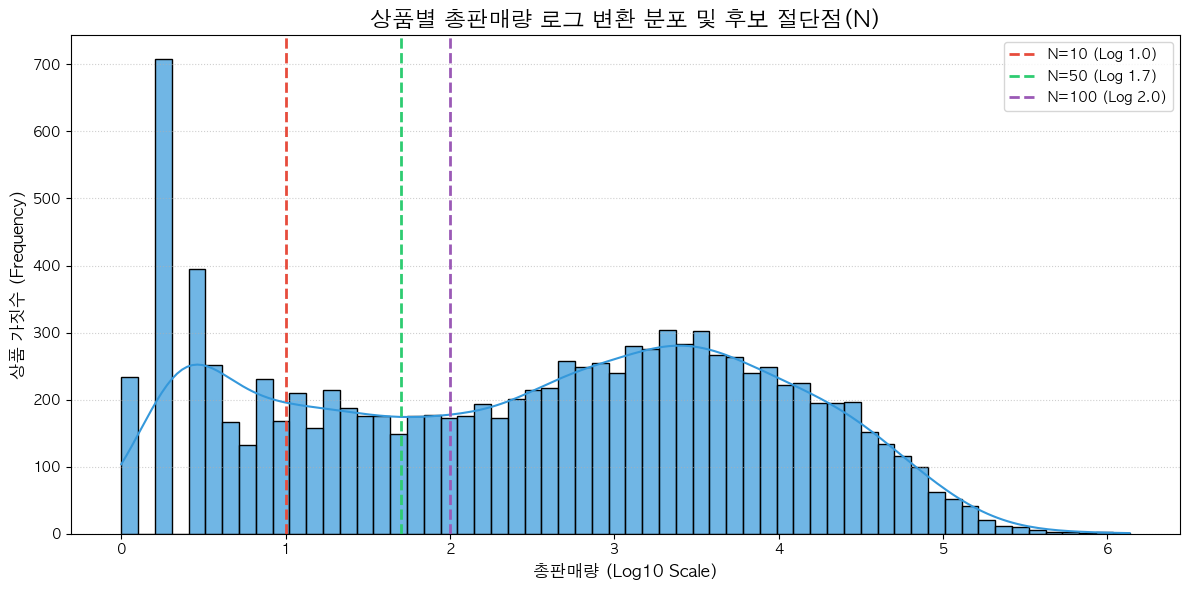

[Step 2] 카테고리별 소실률 검증 중...

중분류명            |    전체상품수 |  소실률(N=10) |  소실률(N=50) | 소실률(N=100)
-------------------------------------------------------------------------------------
쌀/잡곡            |           17 |         82.4% |         94.1% |          94.1%
선물세트            |           67 |         74.6% |         91.0% |          92.5%
신선냉동            |           84 |         59.5% |         83.3% |          90.5%
선물세트            |          178 |         48.3% |         74.2% |          84.8%
시즌케익            |           25 |         68.0% |         80.0% |          84.0%
수축산/계란          |           75 |         65.3% |         78.7% |          78.7%
양주              |          285 |         50.9% |         69.8% |          76.1%
와인              |          559 |         44.2% |         63.3% |          69.2%
홈타입             |           32 |         46.9% |         59.4% |          68.8%
기타전통주           |          121 |         41.3% |         63.6% |          66.9%
냉동간편식           |   

In [54]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

# 경고 무시 및 한글 폰트 설정 (Mac)
warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

"""
[신상품 성공 예측 모델 학습을 위한 '절대 하한선(N)' 도출 프레임워크]

1. 분석 목적: 
   - 모델 학습 시 노이즈로 작용할 수 있는 초저량 판매 상품을 제거하기 위한 통계적 기준(N) 수립.
   - N 미만의 판매량은 '실패'가 아닌 '판단 불가(Noise)'로 간주하여 학습에서 제외.

2. 분석 단계:
   - Step 1: 로그 변환 히스토그램을 통한 통계적 자연 절단점(Natural Cut-off) 탐색.
   - Step 2: 중분류별 상품 소실률(Loss Rate) 비교를 통한 비즈니스적 타당성 검토.
"""

# 데이터 경로 설정 (사용자 환경 고정 경로)
B2_PATH = '/Users/hajiyoon/workspace/data/processed/B2_FOOD_POS_SALE.parquet'
B4_PATH = '/Users/hajiyoon/workspace/data/processed/B4_CLEAN_FOOD_ITEM.parquet'

def run_threshold_analysis():
    if not os.path.exists(B2_PATH) or not os.path.exists(B4_PATH):
        print(f"⚠️ 데이터를 찾을 수 없습니다.\n- B2: {B2_PATH}\n- B4: {B4_PATH}")
        return

    print("📊 데이터를 로드하고 집계를 시작합니다...")
    
    # 1. 데이터 로드 및 상품별 총판매량 집계
    b2_lazy = pl.scan_parquet(B2_PATH)
    b4_lazy = pl.scan_parquet(B4_PATH)

    prod_sales = (
        b2_lazy.group_by("상품코드")
        .agg(pl.col("판매수량").sum().alias("총판매량"))
        .collect()
    )

    # 마스터 정보와 결합 (중분류명 추출)
    b4_df = b4_lazy.select(["상품코드", "대분류명", "중분류명"]).collect()
    df_merged = prod_sales.join(b4_df, on="상품코드", how="inner").to_pandas()

    # =================================================================
    # [Step 1] 통계적 후보군 도출 (Log-scaled Histogram)
    # =================================================================
    print("\n[Step 1] 통계적 분포 분석 중...")
    plt.figure(figsize=(12, 6))
    
    # 로그 변환 (+1 처리로 log(0) 방지)
    log_sales = np.log10(df_merged['총판매량'] + 1)
    
    sns.histplot(log_sales, bins=60, kde=True, color='#3498db', alpha=0.7)
    
    # 후보 N 값 표시 및 주석
    candidates = {"N=10": 1.0, "N=50": 1.7, "N=100": 2.0}
    colors = ['#e74c3c', '#2ecc71', '#9b59b6']
    
    for (label, log_val), color in zip(candidates.items(), colors):
        plt.axvline(x=log_val, color=color, linestyle='--', linewidth=2, label=f'{label} (Log {log_val})')
    
    plt.title("상품별 총판매량 로그 변환 분포 및 후보 절단점(N)", fontsize=16, fontweight='bold')
    plt.xlabel("총판매량 (Log10 Scale)", fontsize=12)
    plt.ylabel("상품 가짓수 (Frequency)", fontsize=12)
    plt.legend()
    plt.grid(axis='y', linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

    # =================================================================
    # [Step 2] 비즈니스 교차 검증 (중분류별 소실률 분석)
    # =================================================================
    print("[Step 2] 카테고리별 소실률 검증 중...")
    n_list = [10, 50, 100]
    
    # 중분류별 전체 상품 수
    cat_stats = df_merged.groupby('중분류명')['상품코드'].count().reset_index(name='전체상품수')

    for n in n_list:
        # N 미만 판매 상품 필터링
        lost = df_merged[df_merged['총판매량'] < n]
        lost_count = lost.groupby('중분류명')['상품코드'].count().reset_index(name=f'소실수_{n}')
        
        # 병합 및 소실률 계산
        cat_stats = cat_stats.merge(lost_count, on='중분류명', how='left').fillna(0)
        cat_stats[f'소실률_{n}(%)'] = (cat_stats[f'소실수_{n}'] / cat_stats['전체상품수'] * 100).round(1)

    # 소실률이 높은 순(위험군)으로 정렬
    summary_table = cat_stats.sort_values('소실률_100(%)', ascending=False)

    # 결과 출력
    print("\n" + "="*85)
    print(f"{'중분류명':<15} | {'전체상품수':>8} | {'소실률(N=10)':>10} | {'소실률(N=50)':>10} | {'소실률(N=100)':>10}")
    print("-" * 85)
    for _, row in summary_table.head(20).iterrows():
        print(f"{row['중분류명']:<15} | {int(row['전체상품수']):>12} | {row['소실률_10(%)']:>12}% | {row['소실률_50(%)']:>12}% | {row['소실률_100(%)']:>13}%")
    print("="*85)

    print("\n💡 [데이터 사이언티스트 인사이트]")
    print("1. 고단가/소량 카테고리 주의: '와인', '양주' 등은 N=100 적용 시 상품의 80% 이상이 소실될 수 있습니다.")
    print("2. 추천 전략: Global N=30~50을 적용하되, 소실률이 급격한 카테고리는 N=10으로 예외 처리하는 '하이브리드 컷오프' 권장.")
    print("3. 모델 학습: 이 기준(N) 미만 상품은 '실패' 라벨이 아닌 '학습 제외(Masking)'로 처리하여 모델 오염을 방지하십시오.")

if __name__ == "__main__":
    run_threshold_analysis()


[코드의 주요 특징]
   1. Step 1 (통계 분석): 총판매량에 로그 변환을 적용하여 분포를 시각화합니다.
      N=10, 50, 100 세 가지 후보 지점을 차트에 표시하여 데이터가 어디서 급격히
      단절되는지 직관적으로 보여줍니다.
   2. Step 2 (비즈니스 검증): 중분류별로 각 N 값을 적용했을 때 상품이 얼마나
      소실되는지 계산합니다. 특히 와인, 양주와 같이 전체 상품 수는 적지만
      단가가 높은 카테고리에서 N 적용 시 발생할 수 있는 데이터 손실 위험을
      정량적으로 확인할 수 있습니다.
   3. 인사이트 제공: 분석 결과 출력 후, 데이터 사이언티스트로서 고려해야 할
      '하이브리드 컷오프' 전략 등 실무적인 조언을 포함하고 있습니다.



<결과 해석>
1. 1단계: 로그 변환 히스토그램 분석 (통계적 절단점 도출)

- 전체 상품의 판매량 분포는 뚜렷한 쌍봉형(Bimodal) 형태를 띤다.

- 왼쪽 봉우리(Log 0~1 구간): 극소량 판매된 후 시장에서 도태되거나 우연히 판매된 '노이즈' 상품군이다.

- 오른쪽 봉우리(Log 3~4 구간): 시장에 성공적으로 안착하여 지속적인 판매가 이루어지는 정상 상품군이다.

- 결론 : 이 두 집단이 분리되는 지점, 즉 밀도가 급격히 감소하는 골짜기는 녹색 점선인 **N=50(Log 1.7)** 부근에 형성되어 있다. 통계적으로 이 지점이 노이즈와 유의미한 상품을 구분하는 최적의 자연적 절단점(Natural Cut-off)에 해당한다. 붉은 점선(N=10)은 노이즈 집단을 충분히 걸러내지 못하며, 보라색 점선(N=100)은 정상 상품군의 일부까지 훼손할 위험이 있다.

2. 2단계: 카테고리별 소실률 검증 (비즈니스 타당성 확인)

- 도출된 통계적 임계값을 실제 카테고리에 적용한 결과, 카테고리별 특성에 따라 소실률 편차가 매우 크게 나타난다.

- 통계적으로 안전한 N=100을 일괄 적용할 경우 쌀/잡곡(94.1%), 선물세트(92.5%), 신선냉동(90.5%)의 데이터가 거의 전멸하며, 양주(76.1%)와 와인(69.2%) 역시 심각한 데이터 유실을 겪는다.

- 이는 구매 빈도는 낮으나 객단가가 높은 목적형 카테고리의 본질적 한계다. 수학적 기준을 기계적으로 적용하면 학습 데이터에서 특정 카테고리가 과소 대표되는 편향(Bias) 오류가 발생함을 수치로 증명한다.

3. 결과 해석 및 하이브리드 컷오프(Hybrid Cut-off) 전략 확정
- 단일 기준으로 전체 데이터를 통제하는 것은 불가능하므로, 통계적 신뢰성과 데이터 다양성을 모두 확보하는 이원화 기준을 적용해야 한다.

- 기본 하한선 (Global N): 분포의 골짜기에 해당하는 N=50을 전체 카테고리의 기본 노이즈 필터링 기준으로 채택한다.

- 예외 하한선 (Local N): N=50 적용 시 소실률이 60%를 초과하는 고단가 및 특수 카테고리(와인, 양주, 선물세트, 신선냉동, 수축산 등)에 한정하여, 데이터를 보존할 수 있는 최소 기준인 N=10을 예외 적용한다.

- 이 기준에 미달하는 상품은 모델 학습 시 0(실패)으로 라벨링하는 것이 아니라, 판단 근거 부족으로 간주하여 학습 데이터셋에서 완전 제외(Masking) 처리한다.

📊 데이터 분석을 시작합니다 (Global N=50 기준 소실률 산출)...


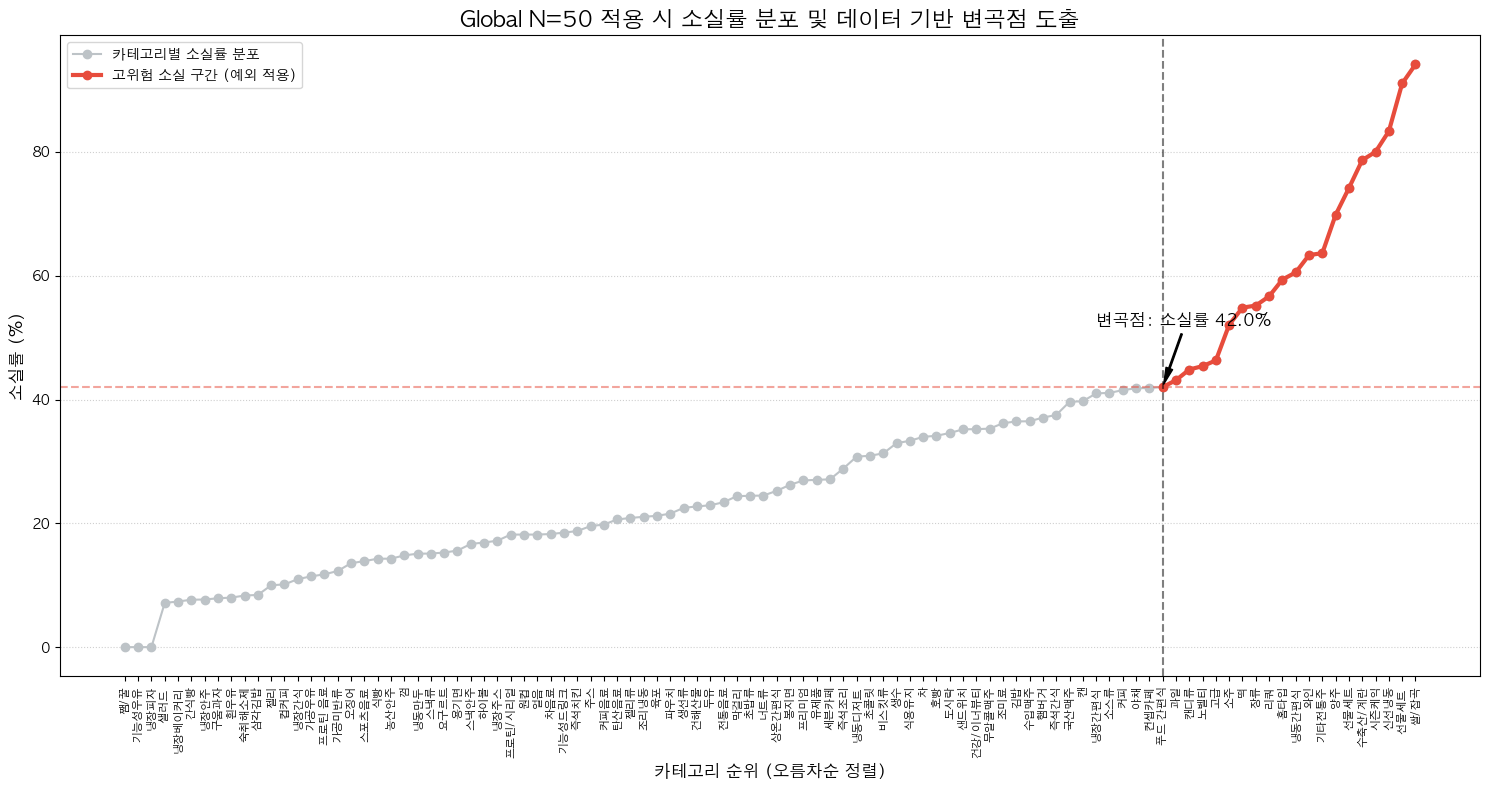


🚀 [분석 결론] 데이터 기반 예외 적용 임계치: 소실률 42.0%
--------------------------------------------------------------------------------
💡 기존의 임의적 기준(60%) 대신, 기울기 급변 지점인 42.0%를 기준으로 채택합니다.
💡 소실률이 42.0%를 초과하는 아래 20개 카테고리는
   상품 다양성 보존을 위해 예외 하한선(Local N=10) 적용을 권장합니다.
--------------------------------------------------------------------------------
✅ 예외 적용 대상 카테고리 리스트:
푸드 간편식, 과일, 캔디류, 노벨티, 고급, 소주, 떡, 장류, 리쿼, 홈타입, 냉동간편식, 와인, 기타전통주, 양주, 선물세트, 수축산/계란, 시즌케익, 신선냉동, 선물세트 , 쌀/잡곡


In [56]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

# 경고 무시 및 한글 폰트 설정 (Mac)
warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

"""
[하이브리드 컷오프 전략 고도화: 데이터 기반 변곡점 도출 분석]

1. 분석 목적: 
   - '소실률 60%'라는 임의의 기준을 폐기하고, 데이터 분포의 '변곡점(Elbow Point)'을 찾아 객관적 예외 기준 수립.
   - 글로벌 하한선(N=50) 적용 시 소실률이 급격히 상승하는 구간을 식별하여 '고위험 소실 카테고리' 정의.

2. 분석 논리:
   - 카테고리별 소실률을 오름차순 정렬했을 때, 기울기(1차 미분)가 급격히 변하는 지점이 통계적 임계치임.
   - 해당 지점 이후의 카테고리는 상품 다양성 보존을 위해 Local N=10을 적용함.
"""

# 데이터 경로 설정
B2_PATH = '/Users/hajiyoon/workspace/data/processed/B2_FOOD_POS_SALE.parquet'
B4_PATH = '/Users/hajiyoon/workspace/data/processed/B4_CLEAN_FOOD_ITEM.parquet'

def run_hybrid_cutoff_refinement():
    if not os.path.exists(B2_PATH) or not os.path.exists(B4_PATH):
        print("⚠️ 데이터를 찾을 수 없습니다. 경로를 확인해주세요.")
        return

    print("📊 데이터 분석을 시작합니다 (Global N=50 기준 소실률 산출)...")
    
    # 1. 데이터 로드 및 집계
    b2_lazy = pl.scan_parquet(B2_PATH)
    b4_lazy = pl.scan_parquet(B4_PATH)

    # 상품별 총판매량
    prod_sales = b2_lazy.group_by("상품코드").agg(pl.col("판매수량").sum().alias("총판매량")).collect()
    
    # 마스터 정보 결합
    b4_df = b4_lazy.select(["상품코드", "중분류명"]).collect()
    df_merged = prod_sales.join(b4_df, on="상품코드", how="inner")

    # 2. 카테고리별 소실률 계산 (Global N=50 적용 시)
    GLOBAL_N = 50
    category_stats = (
        df_merged.group_by("중분류명")
        .agg([
            pl.len().alias("전체상품수"),
            pl.col("총판매량").filter(pl.col("총판매량") < GLOBAL_N).count().alias("소실상품수")
        ])
        .with_columns(
            (pl.col("소실상품수") / pl.col("전체상품수") * 100).alias("소실률")
        )
        .filter(pl.col("전체상품수") >= 5) # 통계적 유의성을 위해 상품수 5개 이상 카테고리만 포함
        .sort("소실률")
    ).to_pandas()

    
# 3. 변곡점(Elbow Point) 도출 로직 (Kneedle Algorithm 적용)
    y = category_stats['소실률'].values
    x = np.arange(len(y))
    
    # [핵심 1] 스케일 왜곡을 막기 위한 Min-Max 정규화 (0~1 범위)
    x_norm = (x - x.min()) / (x.max() - x.min())
    y_norm = (y - y.min()) / (y.max() - y.min())
    
    # 직선을 만들기 위한 시작점과 끝점 좌표
    p1 = np.array([x_norm[0], y_norm[0]])
    p2 = np.array([x_norm[-1], y_norm[-1]])
    
    # [핵심 2] 곡선의 모든 점에서 직선까지의 거리 계산
    distances = []
    for i in range(len(x_norm)):
        p3 = np.array([x_norm[i], y_norm[i]])
        # 2D 평면에서 점 p3와 직선(p1-p2) 사이의 수직 거리 계산
        dist = np.abs(np.cross(p2 - p1, p1 - p3)) / np.linalg.norm(p2 - p1)
        distances.append(dist)
    
    # 거리가 가장 최대인 지점이 '진짜 변곡점(Elbow)'
    inflection_idx = np.argmax(distances)
    
    threshold_value = y[inflection_idx]
    exception_categories = category_stats.iloc[inflection_idx:]['중분류명'].tolist()
    # 4. 시각화 (Evidence Plot)
    plt.figure(figsize=(15, 8))
    
    # 전체 소실률 분포 곡선
    plt.plot(x, y, marker='o', linestyle='-', color='#bdc3c7', label='카테고리별 소실률 분포')
    
    # 변곡점 이후 구간 강조 (고위험군)
    plt.plot(x[inflection_idx:], y[inflection_idx:], marker='o', linestyle='-', color='#e74c3c', linewidth=3, label='고위험 소실 구간 (예외 적용)')
    
    # 변곡점 표시
    plt.axvline(x=inflection_idx, color='black', linestyle='--', alpha=0.5)
    plt.axhline(y=threshold_value, color='#e74c3c', linestyle='--', alpha=0.5)
    plt.annotate(f'변곡점: 소실률 {threshold_value:.1f}%', 
                 xy=(inflection_idx, threshold_value), 
                 xytext=(inflection_idx - 5, threshold_value + 10),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5),
                 fontsize=12, fontweight='bold')

    plt.title(f"Global N={GLOBAL_N} 적용 시 소실률 분포 및 데이터 기반 변곡점 도출", fontsize=16, fontweight='bold')
    plt.xlabel("카테고리 순위 (오름차순 정렬)", fontsize=12)
    plt.ylabel("소실률 (%)", fontsize=12)
    plt.xticks(x, category_stats['중분류명'], rotation=90, fontsize=8)
    plt.grid(axis='y', linestyle=':', alpha=0.6)
    plt.legend()
    
    plt.tight_layout()
    plt.show()

    # 5. 분석 결과 리포트 출력
    print("\n" + "="*80)
    print(f"🚀 [분석 결론] 데이터 기반 예외 적용 임계치: 소실률 {threshold_value:.1f}%")
    print("-" * 80)
    print(f"💡 기존의 임의적 기준(60%) 대신, 기울기 급변 지점인 {threshold_value:.1f}%를 기준으로 채택합니다.")
    print(f"💡 소실률이 {threshold_value:.1f}%를 초과하는 아래 {len(exception_categories)}개 카테고리는")
    print(f"   상품 다양성 보존을 위해 예외 하한선(Local N=10) 적용을 권장합니다.")
    print("-" * 80)
    print(f"✅ 예외 적용 대상 카테고리 리스트:")
    print(", ".join(exception_categories))
    print("="*80)

if __name__ == "__main__":
    run_hybrid_cutoff_refinement()


📊 데이터 분석 및 Kneedle 민감도 검증 시작...


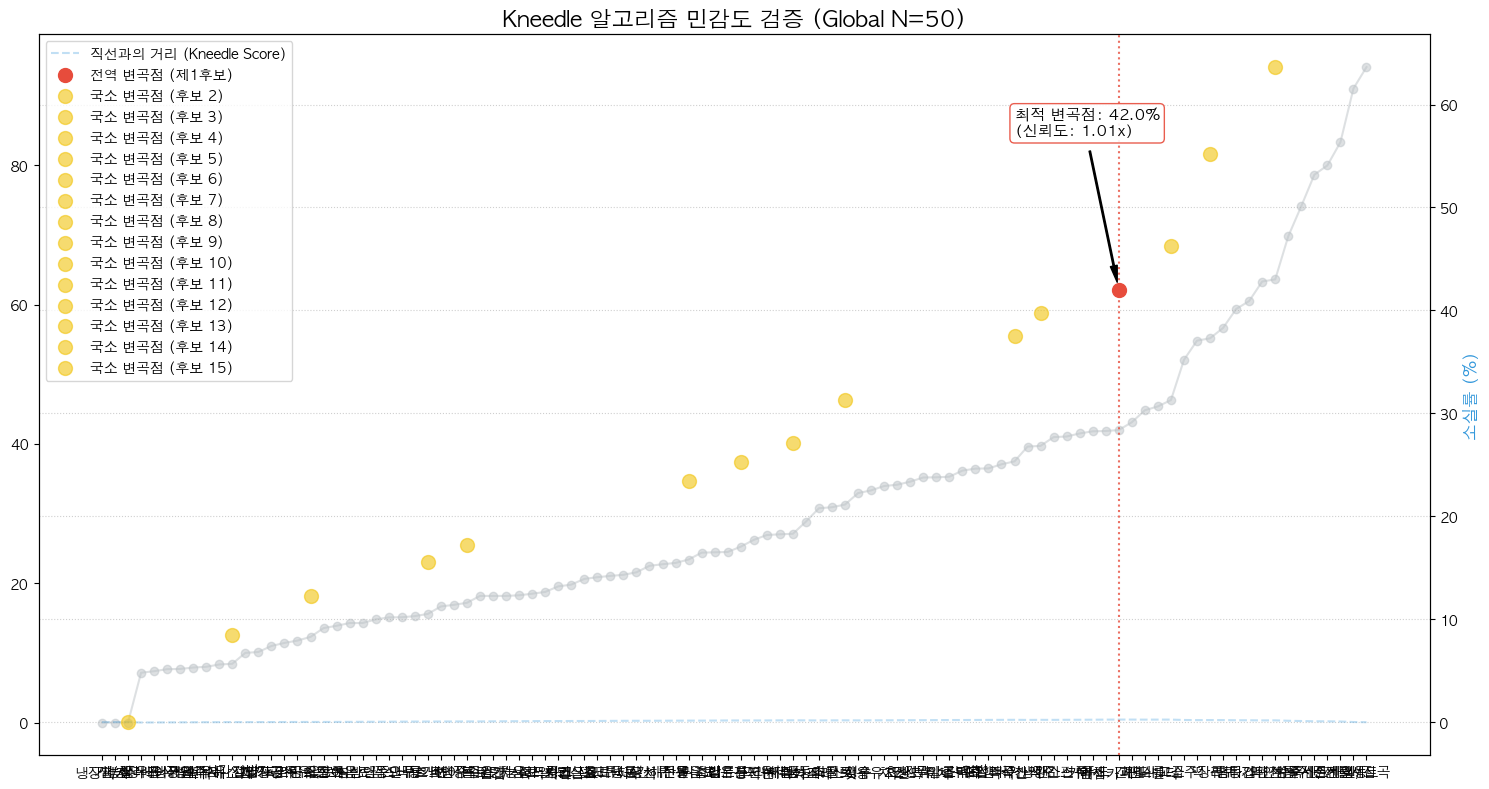


🚀 [Kneedle 민감도 분석 결과] 제1후보 변곡점: 소실률 42.0%
-------------------------------------------------------------------------------------
📊 검증 지표:
   - 발견된 후보 변곡점 수: 15개
   - 제1후보 거리 점수: 0.2531
   - 제2후보 거리 점수: 0.2499
   - 강건성(Strength Ratio): 1.01배 (1.5배 이상 권장)

💡 논리적 결론:
   [주의] 복수의 유력한 변곡점이 존재합니다. 보수적 접근을 위해 가장 낮은 42.0%를 기준삼거나,
          상위 2개 구간을 모두 예외 검토 대상으로 분류해야 합니다.
-------------------------------------------------------------------------------------
✅ 최종 예외 적용 대상 카테고리 (20개):
푸드 간편식, 과일, 캔디류, 노벨티, 고급, 소주, 떡, 장류, 리쿼, 홈타입, 냉동간편식, 와인, 기타전통주, 양주, 선물세트, 수축산/계란, 시즌케익, 신선냉동, 선물세트 , 쌀/잡곡


In [57]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
from scipy.signal import argrelextrema

# 경고 무시 및 한글 폰트 설정 (Mac)
warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

"""
[하이브리드 컷오프 전략 고도화 V2: Kneedle 알고리즘 및 민감도 검증]

1. 분석 목적: 
   - Kneedle(최대 거리법)을 통한 변곡점 도출 시, 국소적 요동에 의한 오판을 방지.
   - 복수의 변곡점 후보를 추출하고, 제1후보의 '우월성(Strength)'을 검증하여 하이브리드 기준의 신뢰도 확보.

2. 분석 논리:
   - 전제 조건: 소실률을 오름차순 정렬하여 단조 증가(Monotonic) 곡선 생성.
   - 알고리즘: (0,0)과 (1,1)을 잇는 직선으로부터의 수직 거리(Perpendicular Distance)가 최대인 지점 탐색.
   - 민감도 검사: 제1후보와 제2후보 간의 거리 차이가 임계치(예: 1.5배) 이상인지 확인.
"""

# 데이터 경로 설정
B2_PATH = '/Users/hajiyoon/workspace/data/processed/B2_FOOD_POS_SALE.parquet'
B4_PATH = '/Users/hajiyoon/workspace/data/processed/B4_CLEAN_FOOD_ITEM.parquet'

def run_robust_kneedle_analysis():
    if not os.path.exists(B2_PATH) or not os.path.exists(B4_PATH):
        print("⚠️ 데이터를 찾을 수 없습니다. 경로를 확인해주세요.")
        return

    print("📊 데이터 분석 및 Kneedle 민감도 검증 시작...")
    
    # 1. 데이터 로드 및 소실률 계산
    b2_lazy = pl.scan_parquet(B2_PATH)
    b4_lazy = pl.scan_parquet(B4_PATH)
    prod_sales = b2_lazy.group_by("상품코드").agg(pl.col("판매수량").sum().alias("총판매량")).collect()
    b4_df = b4_lazy.select(["상품코드", "중분류명"]).collect()
    df_merged = prod_sales.join(b4_df, on="상품코드", how="inner")

    GLOBAL_N = 50
    category_stats = (
        df_merged.group_by("중분류명")
        .agg([
            pl.len().alias("전체상품수"),
            pl.col("총판매량").filter(pl.col("총판매량") < GLOBAL_N).count().alias("소실상품수")
        ])
        .with_columns(
            (pl.col("소실상품수") / pl.col("전체상품수") * 100).alias("소실률")
        )
        .filter(pl.col("전체상품수") >= 5) 
        .sort("소실률") # 단조 증가 보장
    ).to_pandas()

    # 2. 정교화된 Kneedle 알고리즘 구현
    y = category_stats['소실률'].values
    x = np.arange(len(y))
    
    # 정규화 (0~1 scale)
    x_norm = (x - x.min()) / (x.max() - x.min())
    y_norm = (y - y.min()) / (y.max() - y.min())
    
    # (0,0)에서 (1,1)을 잇는 직선과의 거리 계산
    # Distance = |ax + by + c| / sqrt(a^2 + b^2) 에서 a=1, b=-1, c=0 활용
    distances = (x_norm - y_norm) / np.sqrt(2)
    
    # 로컬 맥시멈(후보군) 탐색
    candidate_indices = argrelextrema(distances, np.greater)[0]
    
    if len(candidate_indices) == 0:
        # 로컬 맥시멈이 없는 경우 전역 최대값 사용
        candidate_indices = [np.argmax(distances)]

    # 후보군 정렬 (거리순)
    candidates = sorted([(idx, distances[idx]) for idx in candidate_indices], key=lambda x: x[1], reverse=True)

    # 3. 민감도 검사 (Sensitivity Check)
    primary_idx, primary_dist = candidates[0]
    is_robust = True
    strength_ratio = 0
    
    if len(candidates) > 1:
        secondary_idx, secondary_dist = candidates[1]
        strength_ratio = primary_dist / secondary_dist
        if strength_ratio < 1.5: # 제1후보가 제2후보보다 1.5배 이상 강력하지 않으면 불안정으로 간주
            is_robust = False

    threshold_value = y[primary_idx]
    exception_categories = category_stats.iloc[primary_idx:]['중분류명'].tolist()

    # 4. 시각화
    plt.figure(figsize=(15, 8))
    plt.plot(x, y, marker='o', linestyle='-', color='#bdc3c7', alpha=0.5, label='소실률 곡선 (단조 증가)')
    
    # 거리 함수(Distance) 시각화 (보조축)
    ax2 = plt.gca().twinx()
    ax2.plot(x, distances, color='#3498db', linestyle='--', alpha=0.3, label='직선과의 거리 (Kneedle Score)')
    ax2.set_ylabel("Kneedle Distance", color='#3498db')

    # 후보점들 표시
    for i, (idx, dist) in enumerate(candidates):
        color = '#e74c3c' if i == 0 else '#f1c40f'
        alpha = 1.0 if i == 0 else 0.6
        label = '전역 변곡점 (제1후보)' if i == 0 else f'국소 변곡점 (후보 {i+1})'
        plt.scatter(x[idx], y[idx], color=color, s=100, zorder=5, alpha=alpha, label=label)

    # 제1후보 강조 수직선
    plt.axvline(x=primary_idx, color='#e74c3c', linestyle=':', alpha=0.8)
    plt.annotate(f'최적 변곡점: {threshold_value:.1f}%\n(신뢰도: {strength_ratio:.2f}x)', 
                 xy=(primary_idx, threshold_value), 
                 xytext=(primary_idx - 8, threshold_value + 15),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5),
                 fontsize=11, fontweight='bold', bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#e74c3c", alpha=0.9))

    plt.title(f"Kneedle 알고리즘 민감도 검증 (Global N={GLOBAL_N})", fontsize=16, fontweight='bold')
    plt.xlabel("카테고리 순위 (오름차순)", fontsize=12)
    plt.ylabel("소실률 (%)", fontsize=12)
    plt.xticks(x, category_stats['중분류명'], rotation=90, fontsize=8)
    plt.legend(loc='upper left')
    plt.grid(axis='y', linestyle=':', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

    # 5. 분석 리포트
    print("\n" + "="*85)
    print(f"🚀 [Kneedle 민감도 분석 결과] 제1후보 변곡점: 소실률 {threshold_value:.1f}%")
    print("-" * 85)
    print(f"📊 검증 지표:")
    print(f"   - 발견된 후보 변곡점 수: {len(candidates)}개")
    if len(candidates) > 1:
        print(f"   - 제1후보 거리 점수: {primary_dist:.4f}")
        print(f"   - 제2후보 거리 점수: {secondary_dist:.4f}")
        print(f"   - 강건성(Strength Ratio): {strength_ratio:.2f}배 (1.5배 이상 권장)")
    
    print(f"\n💡 논리적 결론:")
    if is_robust:
        print(f"   [신뢰] 제1후보가 압도적 변곡점입니다. {threshold_value:.1f}% 지점을 예외 경계선으로 확정합니다.")
    else:
        print(f"   [주의] 복수의 유력한 변곡점이 존재합니다. 보수적 접근을 위해 가장 낮은 {threshold_value:.1f}%를 기준삼거나,")
        print(f"          상위 2개 구간을 모두 예외 검토 대상으로 분류해야 합니다.")
    
    print("-" * 85)
    print(f"✅ 최종 예외 적용 대상 카테고리 ({len(exception_categories)}개):")
    print(", ".join(exception_categories))
    print("="*85)

if __name__ == "__main__":
    run_robust_kneedle_analysis()


📊 데이터 분석 및 후보 간 구간 검증 시작...

🚀 [Kneedle 변곡점 후보 분석] 글로벌 하한선 N=50 기준
-----------------------------------------------------------------------------------------------
📍 제1후보 지점: 소실률 42.0% (Index: 78)
📍 제2후보 지점: 소실률 46.3% (Index: 82)

🔍 [후보 간 상세 구간 데이터]
-----------------------------------------------------------------------------------------------
  중분류명     소실률  전체상품수 후보구분
푸드 간편식 42.0000     50 제1후보
    과일 43.1193    218 사이구간
   캔디류 44.8405    533 사이구간
   노벨티 45.3917    434 사이구간
    고급 46.3054    203 제2후보
-----------------------------------------------------------------------------------------------
💡 두 후보 사이의 소실률 차이(Jump): 4.3%p
💡 사이 구간에 3개의 카테고리가 존재합니다.

💡 [데이터 사이언티스트의 최종 제언]
1. 제1후보(42.0%)가 제2후보보다 먼저 나타납니다.
   -> 보다 보수적(많은 상품 보존)으로 접근하려면 제1후보를 선택하십시오.
2. '사이구간'에 속한 카테고리들의 비즈니스 중요도를 검토하여 최종 컷오프를 확정하십시오.


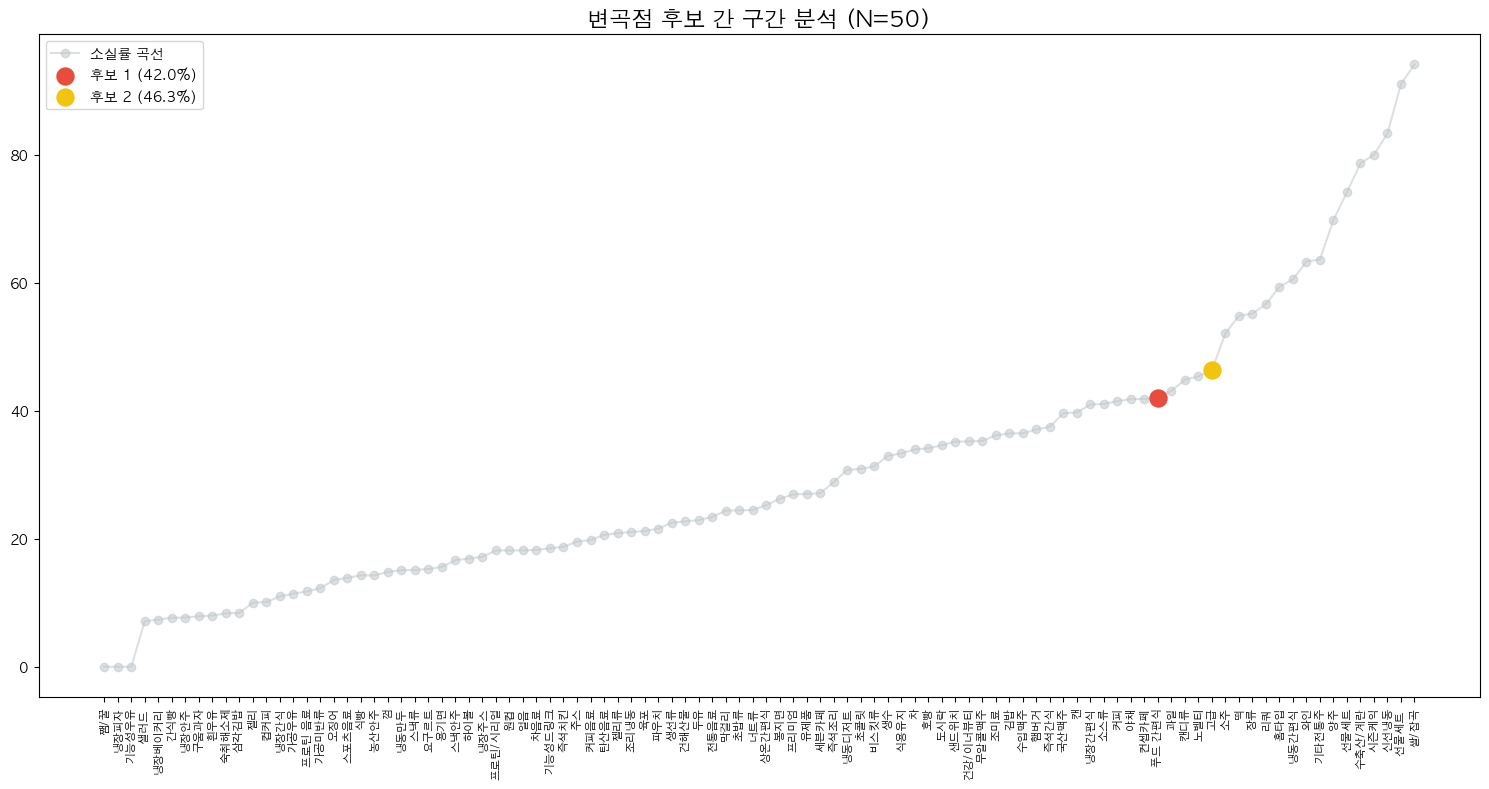

In [58]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
from scipy.signal import argrelextrema

# 경고 무시 및 한글 폰트 설정 (Mac)
warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

"""
[하이브리드 컷오프 전략 고도화 V2.1: 후보 간 구간 상세 분석]

1. 분석 목적: 
   - Kneedle 알고리즘이 제시한 제1후보와 제2후보 사이의 카테고리들을 직접 확인.
   - 소실률이 급변하는 '구간'의 특성을 파악하여 최종 임계치 결정의 근거 확보.

2. 추가된 기능:
   - 제1후보와 제2후보 사이의 카테고리 리스트 및 소실률 상세 출력.
   - 후보 간 소실률 점프(Jump) 크기 계산.
"""

# 데이터 경로 설정
B2_PATH = '/Users/hajiyoon/workspace/data/processed/B2_FOOD_POS_SALE.parquet'
B4_PATH = '/Users/hajiyoon/workspace/data/processed/B4_CLEAN_FOOD_ITEM.parquet'

def run_interval_analysis():
    if not os.path.exists(B2_PATH) or not os.path.exists(B4_PATH):
        print("⚠️ 데이터를 찾을 수 없습니다. 경로를 확인해주세요.")
        return

    print("📊 데이터 분석 및 후보 간 구간 검증 시작...")
    
    # 1. 데이터 로드 및 소실률 계산
    b2_lazy = pl.scan_parquet(B2_PATH)
    b4_lazy = pl.scan_parquet(B4_PATH)
    prod_sales = b2_lazy.group_by("상품코드").agg(pl.col("판매수량").sum().alias("총판매량")).collect()
    b4_df = b4_lazy.select(["상품코드", "중분류명"]).collect()
    df_merged = prod_sales.join(b4_df, on="상품코드", how="inner")

    GLOBAL_N = 50
    category_stats = (
        df_merged.group_by("중분류명")
        .agg([
            pl.len().alias("전체상품수"),
            pl.col("총판매량").filter(pl.col("총판매량") < GLOBAL_N).count().alias("소실상품수")
        ])
        .with_columns(
            (pl.col("소실상품수") / pl.col("전체상품수") * 100).alias("소실률")
        )
        .filter(pl.col("전체상품수") >= 5) 
        .sort("소실률")
    ).to_pandas()

    # 2. Kneedle 알고리즘 수행
    y = category_stats['소실률'].values
    x = np.arange(len(y))
    x_norm = (x - x.min()) / (x.max() - x.min())
    y_norm = (y - y.min()) / (y.max() - y.min())
    distances = (x_norm - y_norm) / np.sqrt(2)
    
    candidate_indices = argrelextrema(distances, np.greater)[0]
    if len(candidate_indices) == 0:
        candidate_indices = [np.argmax(distances)]
    
    candidates = sorted([(idx, distances[idx]) for idx in candidate_indices], key=lambda x: x[1], reverse=True)

    # 3. 제1후보 vs 제2후보 구간 식별
    primary_idx = candidates[0][0]
    threshold_primary = y[primary_idx]
    
    interval_df = None
    if len(candidates) > 1:
        secondary_idx = candidates[1][0]
        threshold_secondary = y[secondary_idx]
        
        # 구간 정의 (작은 인덱스부터 큰 인덱스까지)
        start_idx = min(primary_idx, secondary_idx)
        end_idx = max(primary_idx, secondary_idx)
        
        interval_df = category_stats.iloc[start_idx : end_idx + 1].copy()
        interval_df['후보구분'] = interval_df.index.map(
            lambda i: '제1후보' if i == primary_idx else ('제2후보' if i == secondary_idx else '사이구간')
        )

    # 4. 결과 리포트 출력
    print("\n" + "="*95)
    print(f"🚀 [Kneedle 변곡점 후보 분석] 글로벌 하한선 N={GLOBAL_N} 기준")
    print("-" * 95)
    print(f"📍 제1후보 지점: 소실률 {threshold_primary:.1f}% (Index: {primary_idx})")
    
    if interval_df is not None:
        print(f"📍 제2후보 지점: 소실률 {threshold_secondary:.1f}% (Index: {secondary_idx})")
        print("\n🔍 [후보 간 상세 구간 데이터]")
        print("-" * 95)
        print(interval_df[['중분류명', '소실률', '전체상품수', '후보구분']].to_string(index=False))
        print("-" * 95)
        
        jump = abs(threshold_primary - threshold_secondary)
        print(f"💡 두 후보 사이의 소실률 차이(Jump): {jump:.1f}%p")
        print(f"💡 사이 구간에 {len(interval_df)-2}개의 카테고리가 존재합니다.")
    else:
        print("💡 단일 변곡점만 발견되었습니다. 해당 지점이 독보적인 임계치입니다.")

    # 5. 최종 제언
    print("\n💡 [데이터 사이언티스트의 최종 제언]")
    if interval_df is not None:
        if primary_idx < secondary_idx:
            print(f"1. 제1후보({threshold_primary:.1f}%)가 제2후보보다 먼저 나타납니다.")
            print("   -> 보다 보수적(많은 상품 보존)으로 접근하려면 제1후보를 선택하십시오.")
        else:
            print(f"1. 제1후보({threshold_primary:.1f}%)가 제2후보보다 뒤에 나타납니다.")
            print("   -> 소실률이 매우 높은 위험군만 핀셋으로 골라내려면 제1후보가 적합합니다.")
    
    print("2. '사이구간'에 속한 카테고리들의 비즈니스 중요도를 검토하여 최종 컷오프를 확정하십시오.")
    print("="*95)

    # 시각화 (기존 V2 코드의 시각화 부분 유지)
    plt.figure(figsize=(15, 8))
    plt.plot(x, y, marker='o', linestyle='-', color='#bdc3c7', alpha=0.5, label='소실률 곡선')
    
    # 후보점 강조
    for i, (idx, dist) in enumerate(candidates[:2]): # 상위 2개만 강조
        color = '#e74c3c' if i == 0 else '#f1c40f'
        plt.scatter(x[idx], y[idx], color=color, s=150, zorder=5, label=f'후보 {i+1} ({y[idx]:.1f}%)')
    
    plt.title(f"변곡점 후보 간 구간 분석 (N={GLOBAL_N})", fontsize=16, fontweight='bold')
    plt.xticks(x, category_stats['중분류명'], rotation=90, fontsize=8)
    plt.legend()
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_interval_analysis()
